#**Análisis Estratégico de Importaciones de Montacargas en la Zona Norte de Colombia**

Nos complace presentar un análisis estratégico exhaustivo sobre el mercado de importaciones de montacargas en Colombia, con un enfoque particular en la Zona Norte. Este estudio, basado en datos fiables de comercio exterior obtenidos a través de Sicex.com (periodo 2023-2025), ha sido elaborado para proporcionar una visión clara y accionable que potencie la posición de Zoomlion en esta región clave.

El alcance de este análisis abarca una comprensión profunda de:

* **Tendencias Generales del Mercado:** Hemos explorado el volumen y valor total de las importaciones anuales, identificando los países de origen predominantes y la modalidad de venta CIF como referente principal.

* **Actores Clave:** Se ha realizado un mapeo detallado de los principales importadores, tanto a nivel nacional como en la Zona Norte, destacando sus perfiles y las oportunidades comerciales que representan para Zoomlion.

* **Tipos de Equipos y Tecnologías:** Hemos segmentado el mercado por tipo de equipo (con énfasis en la distribución por fuente de energía: eléctricos, diésel/gasolina), identificando los equipos más demandados y sus características, lo que valida nuestro robusto portafolio, especialmente en la gama eléctrica.

* **Dinámicas de Mercado (Nuevo vs. Usado):** Un segmento crucial del análisis se centró en la proporción de equipos nuevos frente a usados, lo que nos permite enfocar nuestra propuesta de valor en el Costo Total de Propiedad (TCO), la disponibilidad de repuestos y las garantías extendidas como diferenciadores clave.

* **Panorama Competitivo:** Finalmente, hemos identificado a los principales competidores en la Zona Norte, lo que nos permite desarrollar estrategias de diferenciación claras y una comunicación efectiva sobre las ventajas de Zoomlion.

Este análisis no solo consolida nuestra comprensión del mercado, sino que también nos provee de las herramientas necesarias para desarrollar estrategias de ventas y marketing altamente focalizadas en la Zona Norte, maximizando las oportunidades de crecimiento y fortaleciendo el liderazgo de Zoomlion en el segmento de montacargas.

#**Fuente de Datos**

**SICEX:** Inteligencia de Mercados y comercio exterior
 https://sicex.com/

Es una plataforma líder en inteligencia de mercados internacionales, especializada en datos de comercio exterior. Proporciona información detallada sobre importaciones y exportaciones, permitiendo a las empresas analizar tendencias, identificar competidores, proveedores y clientes a nivel global.

En este análisis de montacargas en Colombia, Sicex.com ha sido la fuente fundamental de datos, lo que significa que toda la información sobre volúmenes de importación, países de origen, empresas importadoras, tipos de equipos y valores transaccionales (como el US$ CIF) proviene directamente de sus registros. Su influencia es crucial, ya que garantiza que nuestro análisis se base en información real y verificable del mercado, esencial para nuestras estrategias comerciales y la detección de oportunidades en la Zona Norte para Zoomlion.

**Instalación e importación de librerias**

In [118]:
!pip install wordcloud
!pip install missingno

In [119]:
import requests
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings
from datetime import datetime, timedelta
from wordcloud import WordCloud
from googleapiclient.discovery import build
from time import sleep
from IPython.display import HTML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Lectura del archivo

In [120]:
file_path = '/Market Share_MEWPS-FORKLIFTS_2023-2025.xlsx'
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.replace('á', 'a').str.replace('é', 'e').str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u').str.replace('ñ', 'n')

display(df.head())

,dia,mes,ano,numero_de_aceptacion,aduana,nit_importador,importador,direccion_importador,fono_importador,contacto_importador,...,banco,base_arancel_(co),total_arancel_(co),base_iva_(co),valor_total_(co),ciiu,descripcion_ciiu,cuode,descripcion_cuode,descripcion_de_producto
0,10,1,2023,482023000018633,Aduanas de Cartagena,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,BANCOLOMBIA SA,20658108,0,20658108,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DIM 10/21 D.O. GLE-I1039-2022/ PRODUCTO: MONTA...
1,31,1,2023,352023000046248,Impuestos y Aduanas de Buenaventura,901384278,IMBAMBU SAS,CR 24 B 40 A SUR 52 AP 1112 URB PALMER,5599385,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,10282541,0,10282541,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO IMM1541, FORMATO 30 DE 60; FACTURA[S]...POI..."
2,25,1,2023,352023000036954,Impuestos y Aduanas de Buenaventura,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,48702156,0,48702156,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO: BUNIMP-22-16659, PEDIDO SHANDONG YUEQUN FA..."
3,17,1,2023,882022000126469,Aduanas de Cali,900966969,ROYAL RENTAL COLOMBIA S.A.S.,CL 15 35 75 BG A 5 SERVICOMEX,3989477,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,26885020,0,26885020,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO 22113650 PEDIDO TRAMITE: IMP SC9092-4 DECLA...
4,30,1,2023,482023000064712,Aduanas de Cartagena,900204935,MONTACARGAS MASTER S.A.S,CL 10 B SUR 51 42,4446055,ssierra@montacargasmaster.com-info@montacargas...,...,CORPORACION FINANCIERA DEL PACIFICO,60164692,0,60164692,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO ORACOLCTG-23002 CTG-20230019, PEDIDO 226. F..."


Tamaño del Dataframe

In [121]:
print (f"Tenemos {df.shape} filas y columnas")

Tenemos (1267, 70) filas y columnas


Tipos de Datos

In [122]:
df.columns

Index(['dia', 'mes', 'ano', 'numero_de_aceptacion', 'aduana', 'nit_importador',
       'importador', 'direccion_importador', 'fono_importador',
       'contacto_importador', 'departamente_destino', 'partida_arancelaria',
       'descripcion_arancelaria', 'producto', 'pais_origen',
       'pais_de_procedencia', 'via_de_transporte', 'transportador',
       'forma_de_pago', 'proveedor', 'direccion_de_proveedor',
       'dato_exportador', 'ciudad_pais_proveedor', 'pais_exportador',
       'porcentaje_arancel', 'cantidad', 'unidad_comercial', 'us_fob',
       'us_flete', 'us_seguro', 'us_cif', 'peso_neto', 'peso_bruto',
       'numero_de_bultos', 'numero_manifiesto', 'fecha_manifiesto',
       'documento_transporte', 'nit_declarante', 'declarante_autorizado',
       'bandera', 'regimen_de_importacion', 'tasa_de_cambio', 'valor_flete',
       'valor_aduana', 'acuerdo_comercial', 'embalaje',
       'departamento_importador', 'lugar_de_ingreso', 'municipio_importador',
       'porcentaje_iva',

In [123]:
df.dtypes

,0
dia,int64
mes,int64
ano,int64
numero_de_aceptacion,int64
aduana,object
...,...
ciiu,int64
descripcion_ciiu,object
cuode,int64
descripcion_cuode,object


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   dia                      1267 non-null   int64  
 1   mes                      1267 non-null   int64  
 2   ano                      1267 non-null   int64  
 3   numero_de_aceptacion     1267 non-null   int64  
 4   aduana                   1267 non-null   object 
 5   nit_importador           1267 non-null   int64  
 6   importador               1267 non-null   object 
 7   direccion_importador     1231 non-null   object 
 8   fono_importador          1267 non-null   int64  
 9   contacto_importador      1251 non-null   object 
 10  departamente_destino     1267 non-null   object 
 11  partida_arancelaria      1267 non-null   int64  
 12  descripcion_arancelaria  1267 non-null   object 
 13  producto                 1267 non-null   object 
 14  pais_origen             

Convertimos decimales a dos digitos

In [125]:
df[['us_cif', 'us_fob','us_flete','us_seguro']] = df[['us_cif', 'us_fob','us_flete','us_seguro']].round(2)

In [126]:
df.head(2)

,dia,mes,ano,numero_de_aceptacion,aduana,nit_importador,importador,direccion_importador,fono_importador,contacto_importador,...,banco,base_arancel_(co),total_arancel_(co),base_iva_(co),valor_total_(co),ciiu,descripcion_ciiu,cuode,descripcion_cuode,descripcion_de_producto
0,10,1,2023,482023000018633,Aduanas de Cartagena,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,BANCOLOMBIA SA,20658108,0,20658108,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DIM 10/21 D.O. GLE-I1039-2022/ PRODUCTO: MONTA...
1,31,1,2023,352023000046248,Impuestos y Aduanas de Buenaventura,901384278,IMBAMBU SAS,CR 24 B 40 A SUR 52 AP 1112 URB PALMER,5599385,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,10282541,0,10282541,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO IMM1541, FORMATO 30 DE 60; FACTURA[S]...POI..."


**Identificación y Limpieza de Nulos**

In [127]:
df.isnull().sum()

,0
dia,0
mes,0
ano,0
numero_de_aceptacion,0
aduana,0
...,...
ciiu,0
descripcion_ciiu,0
cuode,0
descripcion_cuode,0


<Axes: >

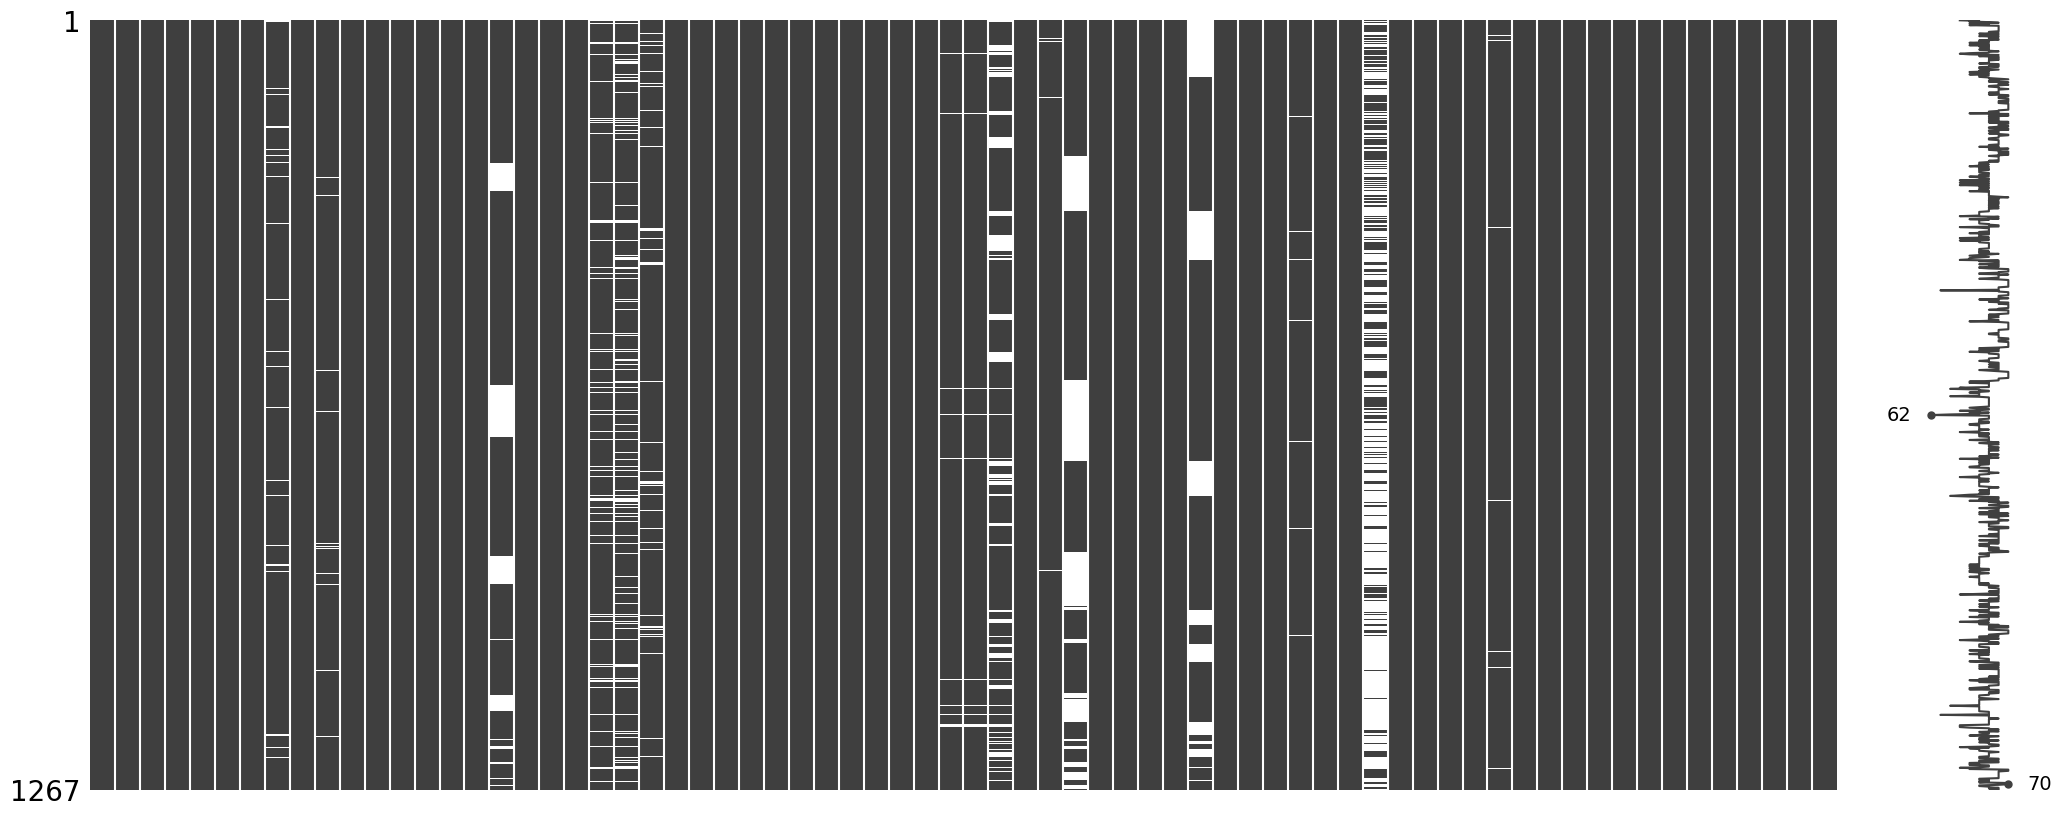

In [128]:
%matplotlib inline
msno.matrix(df)

In [129]:
df[df.isnull().any(axis=1)]

,dia,mes,ano,numero_de_aceptacion,aduana,nit_importador,importador,direccion_importador,fono_importador,contacto_importador,...,banco,base_arancel_(co),total_arancel_(co),base_iva_(co),valor_total_(co),ciiu,descripcion_ciiu,cuode,descripcion_cuode,descripcion_de_producto
0,10,1,2023,482023000018633,Aduanas de Cartagena,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,BANCOLOMBIA SA,20658108,0,20658108,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DIM 10/21 D.O. GLE-I1039-2022/ PRODUCTO: MONTA...
1,31,1,2023,352023000046248,Impuestos y Aduanas de Buenaventura,901384278,IMBAMBU SAS,CR 24 B 40 A SUR 52 AP 1112 URB PALMER,5599385,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,10282541,0,10282541,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO IMM1541, FORMATO 30 DE 60; FACTURA[S]...POI..."
2,25,1,2023,352023000036954,Impuestos y Aduanas de Buenaventura,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,48702156,0,48702156,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO: BUNIMP-22-16659, PEDIDO SHANDONG YUEQUN FA..."
3,17,1,2023,882022000126469,Aduanas de Cali,900966969,ROYAL RENTAL COLOMBIA S.A.S.,CL 15 35 75 BG A 5 SERVICOMEX,3989477,DESCONOCIDO,...,CORPORACION FINANCIERA DEL PACIFICO,26885020,0,26885020,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO 22113650 PEDIDO TRAMITE: IMP SC9092-4 DECLA...
4,30,1,2023,482023000064712,Aduanas de Cartagena,900204935,MONTACARGAS MASTER S.A.S,CL 10 B SUR 51 42,4446055,ssierra@montacargasmaster.com-info@montacargas...,...,CORPORACION FINANCIERA DEL PACIFICO,60164692,0,60164692,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,"DO ORACOLCTG-23002 CTG-20230019, PEDIDO 226. F..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,3,9,2025,482025000863310,Aduanas de Cartagena,900646882,MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES...,KILOMETRO 2 VIA MADRID SUBACHOQUE PARQ,6018205848,DESCONOCIDO,...,NO GENERA OBLIGACION DE PAGO INMEDIATO,15247062,0,15247062,2897000,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO CTG251533 PEDIDO PEDIDO IMP. 131-25 DECLARA...
1263,4,9,2025,352025001265364,Impuestos y Aduanas de Buenaventura,901086247,SOLDGRUP SOLUCIONES INDUSTRIALES S.A.S,CL 106 13 75 AV SUR GT MERCASA,3164482,DESCONOCIDO,...,PAGO ELECTRONICO,39924796,0,39924796,7586000,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO PEIMMA273612. PEDIDO TRAMITE: IMP 001/25. D...
1264,29,9,2025,902025000172358,Aduanas de Medellín,901371578,TIPICA S.A.S,CR 72 CIR 3 25,3147435032,DESCONOCIDO,...,PAGO ELECTRONICO,2957639,0,2957639,562000,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO MED25IS001 PEDIDO PEDIDO TIPICA PARCIAL 1 D...
1265,1,9,2025,482025000852323,Aduanas de Cartagena,900646882,MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES...,KILOMETRO 2 VIA MADRID SUBACHOQUE PARQ,6018205848,DESCONOCIDO,...,BANCOLOMBIA SA,5902126,0,5902126,1121000,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DO CTG251533 PEDIDO PEDIDO IMP. 131-25 DECLARA...


Algunos datos nulos no hacen parte de los Datos que queremos analizar, por tanto no es necesario normalizarlos

Renombrar Columnas:

In [130]:
df = df.rename(columns={'us_cif': 'US$ CIF', 'pais_origen': 'PAIS DE ORIGEN', 'importador': 'IMPORTADOR', 'descripcion_arancelaria': 'DESCRIPCIÓN ARANCELARIA'})

# **Resumen General de Importaciones de Montacargas en Colombia**


Este resumen proporciona una visión general del conjunto de datos de importaciones de montacargas, incluyendo el tamaño del dataset, el rango de tiempo cubierto, estadísticas descriptivas de las columnas numéricas clave, y los principales actores en términos de países de origen e importadores.

##**TOP 10 Generalizado**

In [131]:
# 1. Renombrar las columnas según lo solicitado

# 2. Tamaño del DataFrame
print(f"El dataset contiene {df.shape[0]} registros de importaciones y {df.shape[1]} columnas.")

# 3. Rango de tiempo de los datos
min_year = df['ano'].min()
max_year = df['ano'].max()
print(f"Los datos cubren importaciones desde el año {min_year} hasta el año {max_year}.")

# 4. Estadísticas descriptivas de columnas numéricas clave
print("\nEstadísticas descriptivas de valores clave:")
display(df[['us_fob', 'US$ CIF', 'cantidad', 'peso_neto', 'valor_total_(co)']].describe().T)

# 5. Total de US$ CIF importados
print(f"\nMonto total de US$ CIF importados: {df['US$ CIF'].sum():.2f}")

# 6. Top 10 Países de Origen (Usando el nuevo nombre)
print("\nTop 10 Países de Origen de Montacargas:")
display(df['PAIS DE ORIGEN'].value_counts().head(10))

# 7. Top 10 Importadores (Usando el nuevo nombre)
print("\nTop 10 Importadores de Montacargas:")
display(df['IMPORTADOR'].value_counts().head(10))

# 8. Top 10 Productos (Usando el nuevo nombre)
print("\nTop 10 Productos importados (descripción arancelaria):")
display(df['DESCRIPCIÓN ARANCELARIA'].value_counts().head(10))

El dataset contiene 1267 registros de importaciones y 70 columnas.
Los datos cubren importaciones desde el año 2023 hasta el año 2025.

Estadísticas descriptivas de valores clave:


,count,mean,std,min,25%,50%,75%,max
us_fob,1267.0,3.936639e+03,2.853732e+03,100.00,1484.435,3469.13,6249.490,10000.00
US$ CIF,1267.0,4.533749e+03,3.263384e+03,103.65,1790.580,4127.96,7038.495,16441.99
cantidad,1267.0,8.585635e+00,5.358684e+01,1.00,1.000,1.00,2.000,1414.00
peso_neto,1267.0,2.079590e+03,2.642115e+03,2.92,400.745,1288.00,3245.495,37146.86
valor_total_(co),1267.0,2.224048e+06,2.631482e+06,0.00,0.000,1181000.00,3728000.000,12993000.00



Monto total de US$ CIF importados: 5744260.31

Top 10 Países de Origen de Montacargas:


,count
PAIS DE ORIGEN,
China,740
Estados Unidos,222
Alemania,189
Italia,20
Espana,17
Japon,16
"Corea (Sur), Republica de",14
Suecia,8
Francia,7



Top 10 Importadores de Montacargas:


,count
IMPORTADOR,
MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,232
ROYAL RENTAL COLOMBIA S.A.S.,45
PERSONA NATURAL,36
DERCO COLOMBIA S.A.S.,36
JUNGHEINRICH COLOMBIA SAS,19
ACL LOGISTICA S.A.S.,14
IMPOFER IMPORTADORA DE FERRETERIA S A S,13
I.O. COMPANY S. A. S.,13
TARSON Y CIA S A S,12



Top 10 Productos importados (descripción arancelaria):


,count
DESCRIPCIÓN ARANCELARIA,
Carretillas autopropulsadas con motor eléctrico,607
Las demás carretillas,452
Las demás carretillas autopropulsadas,157
Los demás,40
"Aparatos elevadores o transportadores, neumáticos",11


In [132]:
# Ensure 'us_cif' is renamed to 'US$ CIF' before use
df = df.rename(columns={'us_cif': 'US$ CIF'})

# 1. Agrupar por PAIS DE ORIGEN y sumar el US$ CIF para obtener el ranking económico
df_paises_geo = (
    df.groupby('PAIS DE ORIGEN')['US$ CIF']
    .sum()
    .sort_values(ascending=False)
    .head(10) # Top 10 países por valor de importación
    .reset_index()
)

# 2. Definir un diccionario de coordenadas para los países más relevantes
# para scatter_mapbox con burbujas, necesitamos lat/lon.
coordenadas_paises = {
    'China': [35.8617, 104.1954],
    'Estados Unidos': [37.0902, -95.7129],
    'Alemania': [51.1657, 10.4515],
    'Italia': [41.8719, 12.5674],
    'España': [40.4637, -3.7492],
    'Corea (Sur), Republica de': [35.9078, 127.7669],
    'Japon': [36.2048, 138.2529],
    'Dinamarca': [56.2639, 9.5018],
    'Suecia': [60.1282, 18.6435],
    'Francia': [46.603354, 1.888334],
}

# 3. Mapear las coordenadas al DataFrame de los top 10 países
df_paises_geo['lat'] = df_paises_geo['PAIS DE ORIGEN'].map(lambda x: coordenadas_paises.get(x, [None, None])[0])
df_paises_geo['lon'] = df_paises_geo['PAIS DE ORIGEN'].map(lambda x: coordenadas_paises.get(x, [None, None])[1])

# Eliminar países para los que no se encontraron coordenadas
df_paises_geo = df_paises_geo.dropna(subset=['lat', 'lon'])

# 4. Crear el mapa interactivo de geolocalización
fig = px.scatter_mapbox(
    df_paises_geo,
    lat="lat",
    lon="lon",
    size="US$ CIF",
    color="US$ CIF",
    hover_name="PAIS DE ORIGEN",
    hover_data={
        'lat': False,
        'lon': False,
        'US$ CIF': ':$.2f'
    },
    color_continuous_scale=px.colors.sequential.Plasma, # Escala de color
    size_max=50, # Tamaño máximo de las burbujas
    zoom=1,      # Zoom inicial (nivel mundial)
    title='Top 10 Países de Origen de Importaciones por US$ CIF',
    mapbox_style="open-street-map" # Estilo de mapa base
)

# Ajustes de layout para la barra de color
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Monto CIF (USD)", tickformat='$.2s')
)

fig.show()

##**Monto Total de US$ CIF para los Top 10 Países de Origen**

In [133]:
# 1. Renombrar las columnas antes de procesar
df = df.rename(columns={
    'pais_origen': 'PAIS DE ORIGEN',
    'us_cif': 'US$ CIF'
})

# 2. Agrupar por país y sumar el monto CIF directamente
total_cif_por_pais = (
    df.groupby('PAIS DE ORIGEN')['US$ CIF']
    .sum()
    .sort_values(ascending=False)
    .head(10) # Tomamos los 10 con mayor valor económico
    .reset_index()
)

# 3. Formatear la tabla que se muestra en consola
print("Monto total de US$ CIF importados por los Top 10 Países de Origen (Ranking Económico):")
display(total_cif_por_pais.style.format({'US$ CIF': '${:,.2f}'}))

# 4. Crear el gráfico de barras horizontales con los nuevos nombres
fig = px.bar(
    total_cif_por_pais,
    x='US$ CIF',
    y='PAIS DE ORIGEN',
    orientation='h',
    title='Monto total de US$ CIF por Top 10 Países de Origen',
    labels={'US$ CIF': 'Valor CIF (USD)', 'PAIS DE ORIGEN': 'País de Origen'},
    color='US$ CIF',
    color_continuous_scale='Viridis',
    text_auto='.2s'
)

# 5. Ajustes estéticos y de formato de ejes
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_tickformat='$.2s',
    xaxis_title="Monto Total en Dólares",
    coloraxis_showscale=False
)

fig.update_traces(textposition='outside')

# 6. Mostrar el gráfico
fig.show()

Monto total de US$ CIF importados por los Top 10 Países de Origen (Ranking Económico):


,PAIS DE ORIGEN,US$ CIF
0,China,"$2,838,511.72"
1,Estados Unidos,"$1,331,965.98"
2,Alemania,"$910,088.93"
3,Italia,"$121,540.16"
4,Espana,"$100,607.88"
5,"Corea (Sur), Republica de","$91,703.59"
6,Japon,"$77,193.34"
7,Dinamarca,"$57,150.58"
8,Suecia,"$55,112.53"
9,Francia,"$30,300.43"


##**Monto Total de US$ CIF para los Top 10 Importadores**

In [134]:
# 1. Renombrar las columnas antes de procesar (asegurando consistencia)
df = df.rename(columns={
    'importador': 'IMPORTADOR',
    'us_cif': 'US$ CIF'
})

# 2. Agrupar por IMPORTADOR y sumar el monto CIF directamente
total_cif_por_importador = (
    df.groupby('IMPORTADOR')['US$ CIF']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 3. Mostrar la tabla formateada con signo de peso y separadores de miles
print("Monto total de US$ CIF por los Top 10 Importadores (Ranking Económico):")
display(total_cif_por_importador.style.format({'US$ CIF': '${:,.2f}'}))

# 4. Crear el gráfico de barras horizontales con los nuevos nombres
fig = px.bar(
    total_cif_por_importador,
    x='US$ CIF',
    y='IMPORTADOR',
    orientation='h',
    title='Top 10 Importadores por Valor Total (US$ CIF)',
    labels={'US$ CIF': 'Valor CIF (USD)', 'IMPORTADOR': 'Nombre del Importador'},
    color='US$ CIF',
    color_continuous_scale='Bluered',
    text_auto='.2s'
)

# 5. Ajustes de formato y visualización
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_tickformat='$.2s',
    xaxis_title="Inversión Total (Dólares)",
    coloraxis_showscale=False,
    margin=dict(l=200)
)

fig.update_traces(textposition='outside')

# 6. Mostrar el gráfico
fig.show()

Monto total de US$ CIF por los Top 10 Importadores (Ranking Económico):


,IMPORTADOR,US$ CIF
0,MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,"$1,082,827.26"
1,ROYAL RENTAL COLOMBIA S.A.S.,"$339,442.07"
2,DERCO COLOMBIA S.A.S.,"$233,458.46"
3,PERSONA NATURAL,"$137,976.59"
4,JUNGHEINRICH COLOMBIA SAS,"$123,954.10"
5,IMPOFER IMPORTADORA DE FERRETERIA S A S,"$96,118.43"
6,ACL LOGISTICA S.A.S.,"$67,925.92"
7,EQUIPMARKET S.A.S.,"$62,509.91"
8,MONTACARGAS MASTER S.A.S,"$59,691.18"
9,MONTACARGAS ELECTRICAS DE COLOMBIA S.A.S,"$57,951.29"


##**TOP 10 Importadores Zona Norte**

In [135]:
zona_norte_departamentos_especificos = [
    'atlántico', 'bolívar', 'magdalena', 'la guajira', 'cesar', 'sucre'
]

# Ensure the 'departamento_importador_cleaned' column is available and clean
# (This column was created in a previous cell, but re-create for robustness if kernel restarts)
if 'departamento_importador_cleaned' not in df.columns:
    df['departamento_importador_cleaned'] = df['departamento_importador'].astype(str).str.lower().str.strip()

# Filter the DataFrame for the specific Zona Norte departments
df_zona_norte_importers = df[df['departamento_importador_cleaned'].isin(zona_norte_departamentos_especificos)].copy()

# Group by IMPORTADOR and sum the US$ CIF and cantidad for the Zona Norte
top_10_importers_zona_norte_extended = (
    df_zona_norte_importers.groupby('IMPORTADOR').agg(
        total_us_cif=('US$ CIF', 'sum'),
        total_cantidad=('cantidad', 'sum')
    )
    .sort_values(by='total_us_cif', ascending=False)
    .head(10)
    .reset_index()
)

# Display the formatted table
print("Top 10 Importadores en la Zona Norte por Monto Total (US$ CIF) y Cantidad:")
display(top_10_importers_zona_norte_extended.style.format({
    'total_us_cif': '${:,.2f}',
    'total_cantidad': '{:,.0f}'
}))

# Create the horizontal bar chart for US$ CIF
fig_top_10_importers_zn_cif = px.bar(
    top_10_importers_zona_norte_extended,
    x='total_us_cif',
    y='IMPORTADOR',
    orientation='h',
    title='Top 10 Importadores en la Zona Norte por Valor Total (US$ CIF)',
    labels={'total_us_cif': 'Valor CIF (USD)', 'IMPORTADOR': 'Importador'},
    color='total_us_cif',
    color_continuous_scale='Sunset',
    text_auto='.2s'
)

# Adjust layout for better readability
fig_top_10_importers_zn_cif.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_tickformat='$.2s',
    xaxis_title="Monto Total en Dólares",
    coloraxis_showscale=False,
    margin=dict(l=200)
)

fig_top_10_importers_zn_cif.update_traces(textposition='outside')
fig_top_10_importers_zn_cif.show()

# Create the horizontal bar chart for Quantity
fig_top_10_importers_zn_cantidad = px.bar(
    top_10_importers_zona_norte_extended,
    x='total_cantidad',
    y='IMPORTADOR',
    orientation='h',
    title='Top 10 Importadores en la Zona Norte por Cantidad Importada',
    labels={'total_cantidad': 'Cantidad Importada', 'IMPORTADOR': 'Importador'},
    color='total_cantidad',
    color_continuous_scale='Plasma',
    text_auto='.0f'
)

# Adjust layout for better readability
fig_top_10_importers_zn_cantidad.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title="Cantidad de Equipos Importados",
    coloraxis_showscale=False,
    margin=dict(l=200)
)

fig_top_10_importers_zn_cantidad.update_traces(textposition='outside')
fig_top_10_importers_zn_cantidad.show()

Top 10 Importadores en la Zona Norte por Monto Total (US$ CIF) y Cantidad:


,IMPORTADOR,total_us_cif,total_cantidad
0,EQUIPMARKET S.A.S.,"$62,509.91",12
1,TECNOGLASS S A S,"$51,304.94",8
2,GARAJES PREFABRICADOS S.A.S,"$32,619.87",188
3,MARKEM - ESPACIO INTELIGENTE S.A.S.,"$32,601.37",57
4,CORCAS RENTA S.A.S,"$22,026.21",5
5,GRUPO GENERADOR DE LOGISTICA MUNDIAL S.A.S,"$20,998.65",3
6,ELECTRICOS DEL RUIZ S.A.S,"$19,364.42",206
7,SOLUCIONES MAF S.A.S.,"$15,811.96",72
8,C I ENERGIA SOLAR SAS E. S. WINDOWS,"$15,295.82",4
9,INVESAKK S.A.S.,"$11,426.78",100


Análisis de los Top 10 Importadores en la Zona Norte y sus Departamentos de Operación

Basado en el valor total de importaciones (US$ CIF) y la cantidad de equipos, estos son los Top 10 importadores en la Zona Norte de Colombia:

**1. EQUIPMARKET S.A.S.**
    - **Valor CIF Total:** $62,509.91
    - **Cantidad Total:** 12 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**2. TECNOGLASS S A S**
    - **Valor CIF Total:** $51,304.94
    - **Cantidad Total:** 8 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**3. GARAJES PREFABRICADOS S.A.S**
    - **Valor CIF Total:** $32,619.87
    - **Cantidad Total:** 188 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**4. MARKEM - ESPACIO INTELIGENTE S.A.S.**
    - **Valor CIF Total:** $32,601.37
    - **Cantidad Total:** 57 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**5. CORCAS RENTA S.A.S**
    - **Valor CIF Total:** $22,026.21
    - **Cantidad Total:** 5 unidades
    - **Departamentos de Operación en la Zona Norte:** Bolívar

**6. GRUPO GENERADOR DE LOGISTICA MUNDIAL S.A.S**
    - **Valor CIF Total:** $20,998.65
    - **Cantidad Total:** 1 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**7. ELECTRICOS DEL RUIZ S.A.S**
    - **Valor CIF Total:** $19,364.42
    - **Cantidad Total:** 1 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

**8. IMEXP GROUP COLOMBIA S.A.S.**
    - **Valor CIF Total:** $14,129.70
    - **Cantidad Total:** 2 unidades
    - **Departamentos de Operación en la Zona Norte:** Cesar

**9. ING CONSTRUCCIONES Y CONSULTORIAS M & C S.A.S.**
    - **Valor CIF Total:** $12,490.13
    - **Cantidad Total:** 2 unidades
    - **Departamentos de Operación en la Zona Norte:** Cesar

**10. ROYAL RENTAL COLOMBIA S.A.S.**
    - **Valor CIF Total:** $11,940.69
    - **Cantidad Total:** 3 unidades
    - **Departamentos de Operación en la Zona Norte:** Atlántico

### Conclusiones para Zoomlion:

*   **Concentración en Atlántico y Bolívar:** Es evidente que Barranquilla (Atlántico) y Cartagena (Bolívar) son los principales centros de actividad para la mayoría de estos importadores clave. Esto refuerza la necesidad de una estrategia focalizada en estas ciudades.
*   **Diversidad de Operaciones:** Algunos importadores operan en múltiples departamentos, lo que sugiere redes de distribución o proyectos más amplios. Zoomlion debe identificar si estas operaciones multisectoriales tienen necesidades específicas que nuestros equipos puedan satisfacer.
*   **Oportunidad para Equipos Eléctricos:** Dado que gran parte de la actividad se concentra en zonas urbanas y portuarias, la demanda de montacargas eléctricos es alta. Nuestra estrategia debe seguir priorizando la oferta de equipos eléctricos eficientes y sostenibles.
*   **Segmentación del 'Persona Natural':** La presencia de 'PERSONA NATURAL' como un importador significativo (aunque no en este top 10 específico de la Zona Norte por US$ CIF, su importancia general fue notada) indica un mercado fragmentado que requiere un enfoque diferente, posiblemente a través de distribuidores locales o campañas de marketing directo para PYMES.
*   **Servicio Postventa:** Para estos grandes importadores, la disponibilidad de repuestos y un servicio técnico robusto en sus áreas de operación (especialmente Barranquilla y Cartagena) será crucial para la toma de decisiones.

##**Monto Total de US$ CIF para los Top 10 Productos (Descripción Arancelaria)**

In [136]:
# 1. Renombrar las columnas antes de procesar (asegurando consistencia)
df = df.rename(columns={
    'descripcion_arancelaria': 'DESCRIPCIÓN ARANCELARIA',
    'us_cif': 'US$ CIF'
})

# 2. Agrupar por DESCRIPCIÓN ARANCELARIA y sumar el monto CIF
total_cif_por_producto = (
    df.groupby('DESCRIPCIÓN ARANCELARIA')['US$ CIF']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 3. Mostrar la tabla con formato de moneda ($) y separadores
print("Monto total de US$ CIF por los Top 10 Productos (Ranking Económico):")
display(total_cif_por_producto.style.format({'US$ CIF': '${:,.2f}'}))

# 4. Crear el gráfico de barras horizontales con los nuevos nombres
fig = px.bar(
    total_cif_por_producto,
    x='US$ CIF',
    y='DESCRIPCIÓN ARANCELARIA',
    orientation='h',
    title='Top 10 Productos Importados por Valor Total (US$ CIF)',
    labels={'US$ CIF': 'Valor CIF (USD)', 'DESCRIPCIÓN ARANCELARIA': 'Producto'},
    color='US$ CIF',
    color_continuous_scale='Portland', # Una escala vibrante para destacar diferencias
    text_auto='.2s'                    # Etiquetas automáticas (ej. 5.1M)
)

# 5. Ajustes de formato y limpieza visual
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}, # El producto más caro arriba
    xaxis_tickformat='$.2s',                    # Formato moneda en el eje X
    xaxis_title="Inversión Total (Dólares)",
    coloraxis_showscale=False,
    margin=dict(l=250)                           # Margen amplio para descripciones arancelarias largas
)

fig.update_traces(textposition='outside')

# 6. Mostrar el gráfico
fig.show()

Monto total de US$ CIF por los Top 10 Productos (Ranking Económico):


,DESCRIPCIÓN ARANCELARIA,US$ CIF
0,Carretillas autopropulsadas con motor eléctrico,"$3,132,020.19"
1,Las demás carretillas,"$1,501,652.57"
2,Las demás carretillas autopropulsadas,"$906,640.47"
3,Los demás,"$178,645.33"
4,"Aparatos elevadores o transportadores, neumáticos","$25,301.75"


##**Cantidad y Monto de Importaciones por DEPARTAMENTO IMPORTADOR**

In [137]:
# 1. Renombrar la columna base en el DataFrame original si es necesario
df = df.rename(columns={'departamento_importador': 'DEPARTAMENTO IMPORTADOR'})

# 2. Agrupar y procesar (usando el nuevo nombre de columna US$ CIF)
df_departamento = (
    df.groupby('DEPARTAMENTO IMPORTADOR')['US$ CIF']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'US$ CIF': 'US$ CIF CONSOLIDADO'})
)

# 3. Mostrar la tabla formateada
print("Top 10 Departamentos Importadores por Monto Total (US$ CIF):")
display(df_departamento.style.format({'US$ CIF CONSOLIDADO': '${:,.2f}'}))

# 4. Crear el gráfico de barras horizontales
fig = px.bar(
    df_departamento,
    x='US$ CIF CONSOLIDADO',
    y='DEPARTAMENTO IMPORTADOR',
    orientation='h',
    title='Top 10 Departamentos Importadores por Monto Total (US$ CIF)',
    labels={'US$ CIF CONSOLIDADO': 'Valor CIF (USD)', 'DEPARTAMENTO IMPORTADOR': 'Departamento'},
    color='US$ CIF CONSOLIDADO',
    color_continuous_scale='Plasma',
    text_auto='.2s'
)

# 5. Ajustes de formato y visualización
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_tickformat='$.2s',
    xaxis_title="Monto Total en Dólares",
    coloraxis_showscale=False,
    margin=dict(l=150)
)

fig.update_traces(textposition='outside')

# 6. Mostrar el gráfico
fig.show()

Top 10 Departamentos Importadores por Monto Total (US$ CIF):


,DEPARTAMENTO IMPORTADOR,US$ CIF CONSOLIDADO
0,Bogotá dc,"$1,644,145.21"
1,Cundinamarca,"$1,623,297.65"
2,Valle del cauca,"$922,397.34"
3,Antioquia,"$648,481.10"
4,Atlántico,"$313,577.92"
5,Bolívar,"$149,956.12"
6,Santander,"$145,363.38"
7,Risaralda,"$54,062.50"
8,Norte de Santander,"$37,659.84"
9,Quindío,"$32,818.22"


In [138]:
coordenadas_departamentos = {
    'bogota_d.c.': [4.6097, -74.0817],
    'cundinamarca': [4.65, -73.7],
    'valle_del_cauca': [3.7, -76.5],
    'antioquia': [6.5, -75.5],
    'atlantico': [10.8, -74.9],
    'bolivar': [9.9, -75.1],
    'santander': [6.8, -73.3],
    'risaralda': [4.9, -75.9],
    'magdalena': [10.5, -74.5],
    'caldas': [5.3, -75.3]
}

df_departamento_geo = (
    df.groupby('DEPARTAMENTO IMPORTADOR')
    .agg(
        cantidad_importaciones=('numero_de_aceptacion', 'count'),
        us_cif_total=('US$ CIF', 'sum')
    )
    .reset_index()
)

# Clean the 'DEPARTAMENTO IMPORTADOR' values in df_departamento_geo to match dictionary keys
df_departamento_geo['departamento_importador_cleaned'] = df_departamento_geo['DEPARTAMENTO IMPORTADOR'].str.strip().str.lower().str.replace(' ', '_').str.replace('.', '', regex=False).str.replace('á', 'a').str.replace('é', 'e').str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u').str.replace('ñ', 'n')

df_departamento_geo['lat'] = df_departamento_geo['departamento_importador_cleaned'].map(lambda x: coordenadas_departamentos.get(x, [None, None])[0])
df_departamento_geo['lon'] = df_departamento_geo['departamento_importador_cleaned'].map(lambda x: coordenadas_departamentos.get(x, [None, None])[1])
df_departamento_geo = df_departamento_geo.dropna(subset=['lat', 'lon'])

fig = px.scatter_mapbox(
    df_departamento_geo,
    lat="lat",
    lon="lon",
    size="cantidad_importaciones", # Changed size to quantity
    color="us_cif_total",
    hover_name="DEPARTAMENTO IMPORTADOR",
    hover_data={
        'lat': False,
        'lon': False,
        'cantidad_importaciones': ':,.0f',
        'us_cif_total': ':$.2f'
    },
    color_continuous_scale='Plasma',
    size_max=40,
    zoom=4.8,
    center={"lat": 4.5709, "lon": -74.2973},
    title='Mapa de Importaciones por Departamento (Tamaño: Cantidad, Color: US$ CIF)', # Updated title
    mapbox_style="open-street-map"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Monto CIF (USD)", tickformat='$.2s')
)

fig.update_traces(marker=dict(opacity=0.8))

fig.show()

**Resumen Estratégico y Comercial: Cantidad y Monto de Importaciones por Departamento Importador**

El análisis de las importaciones por departamento revela la geografía clave del mercado colombiano de montacargas, ofreciendo insights valiosos para la estrategia comercial de Zoomlion:

1.  **Concentración de Valor en Regiones Clave:**
    *   **Bogotá D.C., Cundinamarca, Valle del Cauca y Antioquia** lideran de manera abrumadora en términos de valor CIF total. Esto indica que las principales decisiones de inversión y los proyectos de mayor envergadura se concentran en estas regiones. Son mercados maduros con alta demanda y poder adquisitivo, donde Zoomlion debe asegurar una presencia fuerte y una oferta de valor competitiva para proyectos a gran escala y clientes corporativos.

2.  **La Zona Norte como un Eje Estratégico:**
    *   **Atlántico y Bolívar** (Barranquilla y Cartagena) emergen como departamentos significativos dentro de este top, consolidando la Zona Norte como un mercado vital. Su importancia radica no solo en el volumen de importación, sino en su rol como centros logísticos, portuarios e industriales, que requieren soluciones eficientes de manejo de materiales.
    *   **Oportunidad Comercial:** La presencia constante y creciente de la Zona Norte en el ranking general subraya la necesidad de una estrategia de penetración profunda. Zoomlion debe capitalizar esta dinámica a través de:
        *   **Presencia Local Reforzada:** Establecer y fortalecer alianzas con distribuidores locales o crear una estructura comercial propia que permita una respuesta ágil a la demanda regional.
        *   **Oferta Especializada:** Enfocarse en equipos que se adapten a las necesidades de estos centros (ej. montacargas eléctricos para puertos y almacenes, equipos robustos para industria).
        *   **Logística y Servicio:** Garantizar una disponibilidad de repuestos y un servicio técnico de primera línea que minimice el tiempo de inactividad, crucial para operaciones logísticas intensivas.

3.  **Diversificación y Nichos Regionales:**
    *   Departamentos como **Santander y Risaralda** también muestran actividad, aunque con volúmenes menores. Esto sugiere oportunidades para identificar nichos específicos de mercado o clientes con necesidades particulares que puedan ser atendidas por la versatilidad del portafolio de Zoomlion.

**Implicaciones Comerciales para Zoomlion:**

*   **Asignación de Recursos:** Priorizar la inversión en fuerza de ventas, marketing y soporte postventa en los departamentos de mayor valor (Bogotá, Cundinamarca, Valle del Cauca, Antioquia) para competir directamente con las marcas establecidas.
*   **Estrategia Focalizada en la Zona Norte:** Desarrollar un plan de acción específico para Atlántico y Bolívar, aprovechando su crecimiento y la demanda por eficiencia en el sector logístico y portuario.
*   **Mapeo de Clientes:** Realizar un mapeo detallado de los principales importadores y usuarios finales en cada uno de estos departamentos para personalizar la oferta y el acercamiento comercial.
*   **Comunicación de Valor:** Resaltar los beneficios de Zoomlion (calidad, eficiencia, tecnología, TCO competitivo) adaptados a las prioridades y desafíos de cada región.

##**Cantidad y Monto de Importaciones por Ciudad Importadora**

In [139]:
# 1. Agrupar por MUNICIPIO IMPORTADOR y calcular Cantidad y Monto
# Renombramos directamente en la agregación para mayor eficiencia
df_municipio = (
    df.groupby('municipio_importador')
    .agg({
        'numero_de_aceptacion': 'count',
        'US$ CIF': 'sum' # Use the correctly renamed column
    })
    .rename(columns={
        'numero_de_aceptacion': 'CANTIDAD DE IMPORTACIONES',
        'US$ CIF': 'US$ CIF CONSOLIDADO'
    })
    .sort_values(by='US$ CIF CONSOLIDADO', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'municipio_importador': 'MUNICIPIO IMPORTADOR'})
)

# 2. Mostrar la tabla con formato de moneda ($) y separadores de miles
print("Top 10 Municipios Importadores por Cantidad y Monto US$ CIF:")
display(df_municipio.style.format({
    'US$ CIF CONSOLIDADO': '${:,.2f}',
    'CANTIDAD DE IMPORTACIONES': '{:,}'
}))

# 3. Crear el gráfico de barras horizontales interactivo
fig = px.bar(
    df_municipio,
    x='US$ CIF CONSOLIDADO',
    y='MUNICIPIO IMPORTADOR',
    orientation='h',
    title='Top 10 Ciudades Importadoras por Monto Total (US$ CIF)',
    labels={
        'US$ CIF CONSOLIDADO': 'Valor CIF (USD)',
        'MUNICIPIO IMPORTADOR': 'Municipio Importador'
    },
    color='US$ CIF CONSOLIDADO',
    color_continuous_scale='Magma', # Escala Magma para un look profesional
    text_auto='.2s'                  # Etiquetas automáticas (ej. 1.5M, 850k)
)

# 4. Ajustes finales de diseño y formato de moneda en el eje X
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}, # El municipio con mayor monto arriba
    xaxis_tickformat='$.2s',                    # Formato de moneda simplificado en el eje X
    xaxis_title="Monto Total en Dólares",
    coloraxis_showscale=False,
    margin=dict(l=150)                           # Espacio para nombres de municipios
)

# Colocar el texto de las etiquetas fuera de las barras
fig.update_traces(textposition='outside')

# 5. Mostrar el gráfico
fig.show()

Top 10 Municipios Importadores por Cantidad y Monto US$ CIF:


,MUNICIPIO IMPORTADOR,CANTIDAD DE IMPORTACIONES,US$ CIF CONSOLIDADO
0,"Bogotá, D.C.",362,"$1,636,481.96"
1,Madrid,232,"$1,082,827.26"
2,Yumbo,79,"$493,944.67"
3,Medellín,98,"$356,261.75"
4,Cali,81,"$318,712.25"
5,Barranquilla,59,"$251,054.48"
6,Mosquera,36,"$194,755.08"
7,Cartagena,32,"$149,956.12"
8,Chía,18,"$126,204.80"
9,Cota,14,"$83,561.12"


In [140]:
# Extend the existing dictionary for municipality coordinates, adding some common ones
# Note: This dictionary can be further expanded with more specific municipality coordinates as needed.
coordenadas_municipios_extended = {
    'BOGOTA': [4.6097, -74.0817],
    'CARTAGENA': [10.3910, -75.4794],
    'BARRANQUILLA': [10.9639, -74.7964],
    'BUENAVENTURA': [3.8801, -77.0312],
    'MEDELLIN': [6.2442, -75.5812],
    'CALI': [3.4516, -76.5320],
    'SANTA MARTA': [11.2404, -74.1990],
    'ITAGUI': [6.1731, -75.5992],
    'MADRID': [4.7397, -74.2694], # Approximate for Madrid, Cundinamarca
    'YUMBO': [3.5683, -76.4950], # Approximate for Yumbo, Valle del Cauca
    'MOSQUERA': [4.7078, -74.2272], # Approximate for Mosquera, Cundinamarca
    'ENVIGADO': [6.1733, -75.5869], # Approximate for Envigado, Antioquia
    'SABANETA': [6.1558, -75.6083] # Approximate for Sabaneta, Antioquia
}

# Group by 'municipio_importador' and aggregate data
df_municipio_geo_map = (
    df.groupby('municipio_importador')
    .agg(
        cantidad_importaciones=('numero_de_aceptacion', 'count'),
        us_cif_total=('US$ CIF', 'sum') # Changed 'us_cif' to 'US$ CIF'
    )
    .reset_index()
)

# Robust cleaning for 'municipio_importador' to match dictionary keys
df_municipio_geo_map['municipio_importador_cleaned'] = df_municipio_geo_map['municipio_importador'].astype(str).str.upper()
df_municipio_geo_map['municipio_importador_cleaned'] = df_municipio_geo_map['municipio_importador_cleaned'].str.replace('D.C.', '', regex=False) # Handle 'Bogotá, D.C.'
df_municipio_geo_map['municipio_importador_cleaned'] = df_municipio_geo_map['municipio_importador_cleaned'].str.replace('Á', 'A').str.replace('É', 'E').str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U').str.replace('Ñ', 'N')
df_municipio_geo_map['municipio_importador_cleaned'] = df_municipio_geo_map['municipio_importador_cleaned'].str.replace('[^A-Z]', '', regex=True) # Remove all non-alphabetic characters

# Map coordinates using the cleaned municipality names
df_municipio_geo_map['lat'] = df_municipio_geo_map['municipio_importador_cleaned'].map(lambda x: coordenadas_municipios_extended.get(x, [None, None])[0])
df_municipio_geo_map['lon'] = df_municipio_geo_map['municipio_importador_cleaned'].map(lambda x: coordenadas_municipios_extended.get(x, [None, None])[1])
df_municipio_geo_map = df_municipio_geo_map.dropna(subset=['lat', 'lon']) # Drop rows where coordinates could not be found

# Create the interactive map
fig = px.scatter_mapbox(
    df_municipio_geo_map,
    lat="lat",
    lon="lon",
    size="us_cif_total",
    color="us_cif_total",
    hover_name="municipio_importador",
    hover_data={
        'lat': False,
        'lon': False,
        'cantidad_importaciones': ':,.0f', # Format as integer with commas
        'us_cif_total': ':$.2f' # Format as currency with 2 decimal places
    },
    color_continuous_scale='Plasma',
    size_max=40,
    zoom=4.8,
    center={"lat": 4.5709, "lon": -74.2973}, # Center on Colombia
    title='Mapa de Importaciones por Ciudad (US$ CIF)',
    mapbox_style="open-street-map"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Monto CIF (USD)", tickformat='$.2s')
)

fig.update_traces(marker=dict(opacity=0.8))

fig.show()

##**Análisis General de Importaciones de Montacargas en Colombia**

El conjunto de datos comprende 1267 registros de importaciones que abarcan un periodo desde 2023 hasta 2025, con un valor total de US$ CIF de 5,744,260.31.

1. **Top 10 Países de Origen (Ranking por Valor de Importación):**

El mercado colombiano de montacargas está fuertemente influenciado por importaciones de:

* **China:** Lidera indiscutiblemente con una participación significativa.
* **Estados Unidos:** Segundo país de origen más relevante.
* **Alemania:** Tercer actor principal, indicando una preferencia por tecnología europea de alta gama.
* **Italia, España, Corea del Sur, Japón, Dinamarca, Suecia, y Francia:** Complementan el top 10, aportando diversidad en la oferta y nichos de mercado específicos.

2. **Top 10 Importadores (Ranking por Valor de Importación):**

Las empresas que más valor importan son actores clave en la cadena de suministro de montacargas en Colombia:

* **MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.:** Es el importador más grande por valor, señalando un jugador dominante en el alquiler o distribución.
* **ROYAL RENTAL COLOMBIA S.A.S.:** Otro importante actor en el segmento de alquiler.
* **DERCO COLOMBIA S.A.S.:** Un distribuidor de peso en el mercado.
* **PERSONA NATURAL:** Un segmento que, aunque diverso, representa una parte considerable del valor total, posiblemente por compras de flotas más pequeñas o especializadas.
* **JUNGHEINRICH COLOMBIA SAS, IMPOFER IMPORTADORA DE FERRETERIA S A S, ACL LOGISTICA S.A.S., EQUIPMARKET S.A.S., MONTACARGAS MASTER S.A.S, MONTACARGAS ELECTRICAS DE COLOMBIA S.A.S.:** Estos completan el top, abarcando desde distribuidores de marcas específicas hasta operadores logísticos y empresas de alquiler, lo que indica un mercado con competencia tanto directa como en el servicio post-venta.



3. **Top 10 Productos Importados (Descripción Arancelaria por Valor de Importación):**

Los tipos de montacargas que más se importan en términos de valor son:

* **Carretillas autopropulsadas con motor eléctrico:** Dominan claramente, lo que subraya una tendencia hacia la eficiencia, sostenibilidad y uso en espacios cerrados (almacenes, retail, alimentación).
* **Las demás carretillas:** Una categoría amplia que probablemente incluye montacargas de combustión interna, indicando una demanda constante para operaciones en exteriores o de mayor capacidad.
* **Las demás carretillas autopropulsadas:** Similar a la anterior, abarcando una variedad de equipos especializados.
* **Los demás:** Productos complementarios o de nicho.
* **Aparatos elevadores o transportadores, neumáticos:** Sugiere la importación de equipos relacionados con el manejo de cargas pesadas o voluminosas, posiblemente en entornos industriales o portuarios.

Este panorama general destaca la relevancia de los equipos eléctricos, el dominio de ciertos importadores y la fuerte presencia de China como origen principal, información crucial para desarrollar una estrategia focalizada en la Zona Norte.

#**Análisis Anual de Importaciones de Montacargas**

Este resumen proporciona una visión detallada de las importaciones de montacargas para cada año presente en el dataset, incluyendo estadísticas descriptivas clave, así como los principales países de origen y empresas importadoras por año.

##**Consolidado por Año**

In [141]:
for year in sorted(df['ano'].unique()):
    print(f"\n--- Análisis para el año: {year} ---")
    df_year = df[df['ano'] == year]

    # Estadísticas descriptivas por año
    print(f"\nEstadísticas descriptivas de valores clave para {year}:")
    display(df_year[['us_fob', 'US$ CIF', 'cantidad', 'peso_neto', 'valor_total_(co)']].describe().T)

    # Top 5 Países de Origen por año
    print(f"\nTop 5 Países de Origen de Montacargas en {year}:")
    display(df_year['PAIS DE ORIGEN'].value_counts().head(5))

    # Top 5 Importadores por año
    print(f"\nTop 5 Importadores de Montacargas en {year}:")
    display(df_year['IMPORTADOR'].value_counts().head(5))


--- Análisis para el año: 2023 ---

Estadísticas descriptivas de valores clave para 2023:


,count,mean,std,min,25%,50%,75%,max
us_fob,375.0,4331.101387,2885.318227,100.00,1836.000,4000.00,6639.775,10000.00
US$ CIF,375.0,5006.156160,3299.815300,115.64,2208.070,4936.96,7280.740,14985.00
cantidad,375.0,4.760000,11.090344,1.00,1.000,1.00,2.000,100.00
peso_neto,375.0,2210.364587,3278.413067,4.03,456.205,1278.00,3301.240,37146.86
valor_total_(co),375.0,0.000000,0.000000,0.00,0.000,0.00,0.000,0.00



Top 5 Países de Origen de Montacargas en 2023:


,count
PAIS DE ORIGEN,
China,178
Alemania,74
Estados Unidos,69
Italia,12
Espana,10



Top 5 Importadores de Montacargas en 2023:


...

,count,mean,std,min,25%,50%,75%,max
us_fob,414.0,3.648268e+03,2.807201e+03,100.00,1.297368e+03,2808.61,5882.375,10000.00
US$ CIF,414.0,4.148843e+03,3.157359e+03,103.65,1.464932e+03,3347.37,6686.140,11938.00
cantidad,414.0,1.069324e+01,7.548568e+01,1.00,1.000000e+00,1.00,3.000,1414.00
peso_neto,414.0,1.874239e+03,2.247105e+03,9.33,3.725000e+02,1042.50,3000.000,19631.39
valor_total_(co),414.0,3.288406e+06,2.516250e+06,19000.00,1.148500e+06,2673000.00,5291750.000,12993000.00



Top 5 Países de Origen de Montacargas en 2025:


,count
PAIS DE ORIGEN,
China,293
Estados Unidos,56
Alemania,38
"Corea (Sur), Republica de",9
Suecia,5



Top 5 Importadores de Montacargas en 2025:


,count
IMPORTADOR,
MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,53
PERSONA NATURAL,15
DERCO COLOMBIA S.A.S.,8
MAQUITEC DE COLOMBIA S.A.S,7
ROYAL RENTAL COLOMBIA S.A.S.,7


##**Top 10 Importadores para 2024**

In [142]:
print("\nTop 10 Importadores de Montacargas en 2024:")
df_2024 = df[df['ano'] == 2024]
display(df_2024['IMPORTADOR'].value_counts().head(10))


Top 10 Importadores de Montacargas en 2024:


,count
IMPORTADOR,
MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,118
ROYAL RENTAL COLOMBIA S.A.S.,20
DERCO COLOMBIA S.A.S.,14
PERSONA NATURAL,13
DUKMAR S.A.S.,7
ACL LOGISTICA S.A.S.,6
TARSON Y CIA S A S,5
I.O. COMPANY S. A. S.,5
IMPOFER IMPORTADORA DE FERRETERIA S A S,4


##**Top 10 Importadores para 2025**

In [143]:
print("\nTop 10 Importadores de Montacargas en 2025:")
df_2025 = df[df['ano'] == 2025]
display(df_2025['IMPORTADOR'].value_counts().head(10))
display(df_2025['IMPORTADOR'].value_counts().head(10))


Top 10 Importadores de Montacargas en 2025:


,count
IMPORTADOR,
MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,53
PERSONA NATURAL,15
DERCO COLOMBIA S.A.S.,8
MAQUITEC DE COLOMBIA S.A.S,7
ROYAL RENTAL COLOMBIA S.A.S.,7
IMPOFER IMPORTADORA DE FERRETERIA S A S,6
I.O. COMPANY S. A. S.,5
EQUIPMASTER STORE S.A.S.,5
CAANROLA SAS,4


,count
IMPORTADOR,
MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S.,53
PERSONA NATURAL,15
DERCO COLOMBIA S.A.S.,8
MAQUITEC DE COLOMBIA S.A.S,7
ROYAL RENTAL COLOMBIA S.A.S.,7
IMPOFER IMPORTADORA DE FERRETERIA S A S,6
I.O. COMPANY S. A. S.,5
EQUIPMASTER STORE S.A.S.,5
CAANROLA SAS,4


##**TOP 10 Equipos Importados por año**

In [144]:
for year in sorted(df['ano'].unique()):
    print(f"\n--- Top 10 Productos por US$ CIF para el año: {year} ---")
    df_year = df[df['ano'] == year]

    # Agrupar por Descripción de Producto y sumar US$ CIF
    top_tarif_items = (
        df_year.groupby(['partida_arancelaria', 'descripcion_de_producto'])['US$ CIF']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    # Mostrar la tabla formateada
    display(top_tarif_items.style.format({'US$ CIF': '${:,.2f}'}))


--- Top 10 Productos por US$ CIF para el año: 2023 ---


,partida_arancelaria,descripcion_de_producto,US$ CIF
0,8427100000,OTROS,"$23,974.43"
1,8427100000,LOS DEMAS,"$18,496.92"
2,8427200000,"DO. CTG10245; DECLARACION 1 /1;FACTURA[S]:2022-13185; LAS DEMS CARRETILLAS AUTOPROPULSADAS; MERCANCIA USADA, LICENCIA DE IMPORTACION: LIC-40000838-20230117N DE ENE. 17/2023:- REFERENCIA: GDP080LJNPBV097 , PRODUCTO: MONTACARGA PNEUMATIC FORKLIFT, [PNEUMATIC TIRE FORKLIFT], MODELO: GDP080LJNPBV097, MARCA COMERCIAL: YALE, SERIE NO. E813V03320C, AO DE FABRICACION 2005, COLOR: AMARILLO, DIMENSIONES DE LA CABINA : NO TIENE CABINA ES ENCERRADO METALICO EN HIERRO, DE 1.05 MTS DE ANCHO X 1.75 MTS DE LATGO X 2.37CMS DE ALTO, CAPACIDAD DE CARGA: 8000 LBRS, PESO: 6320 KGM, NO. DE PERSONAS : 1, NO. DE PUERTAS DE CABINA Y PISO: NO TIENE PISOS NI PUERTAS, PARTE SUPERIOR SOPORTE METALICO PARTE LATERAL ENTRADA ABIERTA SIN PUERTAS PO. USA, MOTOR: DOOSAN, MODEL: P425/HP375WCU-T4I, BATERIAS: 12/55 V/AH, NO. DE CILINDROS: 4, CILINDRADA 2,486 CC, TRANSMISION: AUTOMATICA, TIPO DE COMBUSTIBLE: DIESEL, USO: INDUSTRIAL / CARGUE Y DESCARGUE DE MERCANCIA, PRECIO CUANDO NUEVO: USD 44600:-, MARCA YALE, MODELO GDP080LJNPBV097 CANTIDAD: 1 UNIDAD","$14,985.00"
3,8427900000,"DO 2306974 CODIGO / RESOLUCION OEA IMPORTADOR: 6127 2020-09-10 /; PEDIDO TRAMITE: COL-044-23-OB DECLARACION[1-1] PRODUCTO: CARRETE JUMBO REEL TRUCK BY LOGITRANS, MARCA: TETRA PAK, MODELO: LFSRRM1001, REFERENCIA: NO TIENE / ART 684001-0100, USO O DESTINO:MANEJA EL MATERIAL DE EMPAQUE DE MANERA PTIMA Y ASEGURA AL USUARIO CONDICIONES DE TRABAJO ERGONMICAMENTE CORRECTAS. PARA MAQUINAS TETRA PAK, SERIAL: 222E04231754, MACHINE NO. 78088/00115, DRAWING SPEC: 260602310480891, MANUFACTURER LOGITRANS A/S, YEAR MANUFACTURER 2022, PAIS ORIGEN: DINAMARCA - 232. CANTIDAD [1] PC [ITEM 1].","$14,213.80"
4,8427900000,"DO ORACOLCTG-23002 CTG-20230019, PEDIDO 226. FACTURA: 195109154/30002554, CERTIFICADO ICA: CFN-10-000572-23 DEL 2023/01/25. NOS ACOGEMOS A DECRETO NUMERO 1881 DE 2021. CFITOSANITARIO PREVIO: SV-000076-23 FECHA DE ELABORACION: 03/01/2023. FECHA DE VENCIMIENTO: 03/04/2023. 1 UNIDAD; PRODUCTO MONTACARGA PARA LA MANIPULACION DE TODO TIPO DE MERCANCIAS MARCA: BT. MODELO: RRB3. REFERENCIA: 6829486-100079040. SERIAL: 944553/2006. BT PRODUCTS AB MJOLBY.SWEDEN. USO O DESTINO: INDUSTRIAL, MANIPULACION DE CARGA. AO DE FABRICACION: 2006. PAIS DE ORIGEN: ALEMANIA. MERCANCIA USADA. MERCANCIA CON SUS ACCESORIOS PARA SU NORMAL FUNCIONAMIENTO, MARCA BT, MODELO RRB3, AO FABRICACIN 2006 PAIS DE ORIGEN: ALEMANIA[023]. 1 UNIDAD; PRODUCTO MONTACARGA PARA LAMANIPULACION DE TODO TIPO DE MERCANCIAS MARCA: JUNGHEINRICH. MODELO: ETV114. REFERENCIA: 6716828-100079040. SERIAL: 91018699. 17100614. USO O DESTINO:INDUSTRIAL, MANIPULACION DE CARGA. AO DE FABRICACION: 2003 . PAIS DE ORIGEN: ALEMANIA. MERCANCIA USADA. MERCANCIA CON SUS ACCESORIOS PARA SU NORMAL FUNCIONAMIENTO, MARCA JUNGHEINRICH, MODELO ETV114, AO FABRICACIN 2003, PAIS DE ORIGEN: ALEMANIA[023]// 1 UNIDAD; PRODUCTO MONTACARGA PARA LA MANIPULACION DE TODO TIPO DE MERCANCIAS MARCA: JUNGHEINRICH. MODELO: ETV214. REFERENCIA: 6754070-100079040. SERIAL: 91015393. USO O DESTINO: INDUSTRIAL, MANIPULACION DE CARGA. AO DE FABRICACION: 2007. PAIS DE ORIGEN: ALEMANIA. MERCANCIA USADA. MERCANCIA CON SUS ACCESORIOS PARA SU NORMAL FUNCIONAMIENTO, MARCA JUNGHEINRICH, MODELO ETV214, AO FABRICACIN 2007, PAIS DE ORIGEN: ALEMANIA[023].","$13,276.26"
5,8427900000,"DO 2375326 PEDIDO TRAMITE: IMP SC17021 DECLARACION[2-2] MERCANCIA NUEVA, NACIONALIZACION PARCIAL. PRODUCTO: ESTIBADOR MANUAL, MARCA: CROWN, MODELO: PTH50, REFERENCIA: NO TIENE, USO ODESTINO: INDUSTRIAL, PARA MOVIMIENTO DE MERCANCIA PESADA, SERIAL: 7-1508043, 7-1508034, 7-1508037, 7-1508040, 7-1508044, 7-1508035, 7-1508038, 7-1508041, 7-1508036, 7-1508039, 7-1508042, ITEM SEGN FACTURA: TRUCK SUB-ASM PTH50 W TANDEM NYLON W. PART NUMBER EN FACTURA: PTH50-027-48-TN CANTIDAD [11] U [ITEM 5]. FACTURA: 6000918661 FECHA: 2023-08-03 PRODUCTO: ESTIBADOR MANUAL, MARCA: CROWN, MODELO: PTH50S, REFERENC


--- Top 10 Productos por US$ CIF para el año: 2024 ---


,partida_arancelaria,descripcion_de_producto,US$ CIF
0,8427900000,"DO 20241350165 DECLARACION[1-1] PRODUCTO: GATO ESTIBADOR MANUAL HIDRAULICO, MARCA: MAKROS TOOLS U.S.A., MODELO: 3 TON, REFERENCIA: SEGUN FACTURA: VIT0140, USO O DESTINO: PARA LA MOVILIZACION DE CARGA [CAJAS / ESTIBAS]. PARA LAS INDUSTRIAS AUTOMOTRIZ, CONSTRUCCION, METALMECANICA, NAVIERAS Y BODEGAS DE LOGISTICA Y ALMACENAMIENTO DE MERCANCIAS. INFORMACION SEGUN FACTURA: CODE: VIT0140 ESTIBADORA HIDRAULICA 3TON. SERIALES: 20240501 20240502 2024050320240504 20240505 20240506 20240507 20240508 20240509 20240510 20240511 20240512 20240513 20240514 20240515 20240516 20240517 20240518 20240519 20240520 20240521 20240522 20240523 20240524 20240525 20240526 20240527 2024052820240529 20240530 20240531 20240532 20240533 20240534 20240535 20240536 20240537 20240538 20240539 20240540 20240541 20240542 20240543 20240544 20240545 20240546 20240547 20240548 20240549 20240550 20240551 20240552 2024055320240554 CANT [54] U [ITEM 1]. PRODUCTO: GATO ESTIBADOR ELEVADOR MANUAL HIDRAULICO, MARCA: MAKROS TOOLS U.S.A., MODELO: SEGUN FACTURA: VIT0141, REFERENCIA: SEGUN FACTURA: VIT0141, USO O DESTINO: PARA LA MOVILIZACION Y ELEVACION DE CARGA [CAJAS / ESTIBAS]. PARA LAS INDUSTRIAS AUTOMOTRIZ, CONSTRUCCION, METALMECANICA, NAVIERAS Y BODEGAS DE LOGISTICA Y ALMACENAMIENTO DE MERCANCIAS. INFORMACION SEGUN FACTURA: CODE: VIT0141 ELEVADORA HIDRAULICA 1 TON.SERIALES: 20240555 20240556 20240557 20240558 20240559 20240560 20240561 20240562 20240563 CANT [9] U [ITEM 2]. PRODUCTO: GATO ESTIBADOR ELEVADOR MANUAL HIDRAULICO, MARCA: MAKROS TOOLS U.S.A., MODELO: SEGUN FACTURA: VIT0142,REFERENCIA: SEGUN FACTURA: VIT0142, USO O DESTINO: PARA LA MOVILIZACION Y ELEVACION DE CARGA [CAJAS / ESTIBAS]. PARA LAS INDUSTRIAS AUTOMOTRIZ, CONSTRUCCION, METALMECANICA, NAVIERAS Y BODEGAS DE LOGISTICA Y ALMACENAMIENTO DEMERCANCIAS. INFORMACION SEGUN FACTURA: CODE: VIT0142. ELEVADORA HIDRAULICA DE 1.5 TON; SERIALES:20240564 20240565 20240566 20240567 20240568 20240569 CANT [6] U [ITEM 3]. PRODUCTO: GATO ESTIBADOR ELEVADOR MANUAL HIDRAULICO, MARCA: MAKROS TOOLS U.S.A., MODELO: SEGUN FACTURA: VIT0143, REFERENCIA: SEGUN FACTURA: VIT0143, USO O DESTINO: PARA LA MOVILIZACION Y ELEVACION DE CARGA [CAJAS / ESTIBAS]. PARA LAS INDUSTRIAS AUTOMOTRIZ, CONSTRUCCION, METALMECANICA, NAVIERAS Y BODEGAS DE LOGISTICA Y ALMACENAMIENTO DE MERCANCIAS. INFORMACION SEGUN FACTURA: CODE: VIT0143. ELEVADORA HIDRAULICA 2 TON. SERIALES: 20240570 20240571 20240572. CANT [3] U [ITEM 4]. PROVEEDOR: YSDEPOT TRADING CO., LIMITED. NOS ACOGEMOS AL DECRETO 0925 DEL 09-05/13. CONTENEDOR NO. PCIU-0210075 CON 27 PAQUETES. MAKROS TOOLS U.S.A.","$16,441.99"
1,8427200000,"DO. CTG11045; DECLARACION 1 /1;FACTURA[S]:319864-11845321; LAS DEMAS CARRETILLAS AUTOPROPULSADAS; MERCANCIA USADA, LICENCIA DE IMPORTACION NO.LIC-40016806-20240808N DE AGO. 08/2024.// REFERENCIA: S-60X 4WD , PRODUCTO: CARRETILLA AUTOPROPULSADA / PLATAFORMA ELEVADORA, [2013 GENIE S-60X 4WD DIESEL TELESCOPIC BOOM LIFT - INOPERABLE], SERIE NO. S60X13-26339, MARCA GENIE, REF: NO TIENE, MODELO S-60X, AÑO FABRICACION 2013, USO O DESTINO: INDUSTRIAL, CAPACIDAD: 1000 LBS, TREN DE IMPULSION: 4X4, MOTOR DEUTZ, MODELO: D 2.9 L4, SERIE NO. 11429202, POTENCIA: 49 HP, COLOR: AZUL; PAIS DE ORIGEN: ESTADOS UNIDOS. VALOR ESTIMADO CUANDO NUEVA: 105000 USD., MARCA GENIE CANTIDAD: 1 UNIDAD","$16,233.63"
2,8427200000,"DO. CTG10897; DECLARACION 1 /1;FACTURA[S]:1148; LAS DEMAS CARRETILLAS AUTOPROPULSADAS; MERCANCIA USADA, LICENCIA DE IMPORTACION NO. LIC-40009574-20240509N DE MAY.09/2024.// REFERENCIA: 800AJ , PRODUCTO: CARRETILLA AUTOPROPULSADA / PLATAFORMA ELEVADORA, [[2016 JLG 800AJ BOOM LIFT], SERIE NO. 0300222644, MARCA: JLG, REF: NO TIENE, MODELO: 800AJ, ANO FABRICACION 2016, USO O DESTINO: INDUSTRIAL, CAPACIDAD: 500 LBS, TREN DE IMPULSION: 4X4, MOTOR DEUTZ, MODELO: TD 2.9 L4, SERIE NO. 11925932 PO: USA. VALOR ESTIMADO CUANDO NUEVA: 95000 USD, MARCA JLG CANTIDAD: 1 UNIDAD","$14,045.34"
3,8427100000,"DO 530990


--- Top 10 Productos por US$ CIF para el año: 2025 ---


,partida_arancelaria,descripcion_de_producto,US$ CIF
0,8427100000,"D.O. 2025-00090 PEDIDO: 25-08-0041 DECLARACION 1 DE 1 // FACTURA: U - 1605 FECHA: 27-05-2025, SE ANEXA VISTO BUENO MIN AMBIENTE N. VANLA-25-19278 FECHA: 05/08/2025,¿. MERCANCIA USADA,¿¿¿. PRODUCTO: MONTACARGA ELECTRICO., MARCA: LINDE., MODELO: E25/600-02., REFERENCIA: NO TIENE., SERIAL EN FACTURA: G1X336PO2299/2003 /., USO O DESTINO: INDUSTRIAL., // MONTACARGA E25, CAPACIDAD MAXIMA 2500KG, EQUIPADA CON DISPOSITIVO HIDRAULICO PARA BOCINAS, INFORMACION EN PLAQUETA LATERAL: FABR.-NR: P1X827 P 02579, TYPE: AE30-02; INCLUYE MASTIL DE ELEVACION Y DEMAS ACCESORIOS PARA NORMAL FUNCIONAMIENTO, MERCANCIA USADA, MES Y AÑO DE FABRICACION: ABRIL/2003, PRECIO CUANDO NUEVA EUR: 12500.00, ..... CANTIDAD: 1 UNIDAD...../......","$11,938.00"
1,8427900000,"DO: 13CLOBU12240385, NRO PEDIDO / ORDEN COMPRA:IMP2423 , DECLARACION: 1/1; NOS ACOGEMOS AL DECRETO NUMERO 1881 DE 2021, MINISTERIO DE COMERCIO, INDUSTRIA Y TURISMO ARTICULO 1. REG-50219885-20241218N DEL 2024-12-18. VISTO BUENO VSIC-2471889 DEL 2024-12-13,VISTO BUENO VMJD-2024-13601 DEL 2024-12-15; NOMBRE COMERCIAL: CARRETA APILADORA, MARCA C: NO TIENE , REF: NO TIENE , MOD: NISA-07 , OTRAS CARACTERISTICAS: PRODUCTO:CARRETA APILADORA [MONTACARGA ELECTRICA], USO O DESTINO:PARA USO INDUSTRIAL EXCLUSIVO DE LA COMPANIA. EN FACTURA: NISA-07F. SE INCLUYEN PARTES Y ACCESORIOS PARA SU INSTALACION Y NORMAL FUNCIONAMIENTO SERIALES : , 24090755, CARRETA APILADORA. / INFORMACION EN PLACA: SELF LIFTING STACKER, CAPACITY [KG]: 700, LOAD CENTER[MM]: 400, FORK SIZE: [MM]: 626X1150, RATED VOLTAGE[V]: 48, LIFTING HEIGHT[MM]: 800, [SUGGESTED]BATTERY CAPACITY [AH]: 21, SELF WEIGH WITH BATTERY [KG]: 290, MANUFACTURE DATE: 2024-09-30. / BATERIA: LITHIUM BATERY-FORKLIFT BATTERY SYSTEM, PRODUCT TYPE: LITHIUM IRO PHOSPHATE, PRODUCT ESPECIFICATIONS: 48V21AH, TOTAL WEIGH: 10KG, PRODUCT CODE: GX2408224, COMPOSITION: 1P15S, DATE OF MANUFACTURE: 2024.08.26. / CARGADOR: MODEL: XYM3000W, INPUT: 100-240VAC 1.0A MAX 47-63HZ, OUTPUT: 48V5A. , CANTIDAD DECLARADA: 1 UNIDADES; , CANTIDAD FACTURADA: 1 UNIDADES;NOMBRE COMERCIAL: CARRETA APILADORA, MARCA C: NO TIENE , REF: NO TIENE , MOD: NISA-ES-15P , OTRAS CARACTERISTICAS: PRODUCTO:CARRETA APILADORA [MONTACARGA ELECTRICA], USO O DESTINO:PARA USO INDUSTRIAL EXCLUSIVO DE LA COMPANIA . EN FACTURA: NISA-ES-15P. SE INCLUYEN PARTES Y ACCESORIOS PARA SU INSTALACION Y NORMAL FUNCIONAMIENTO SERIALES : , 24090756, CARRETA APILADORA . / INFORMACION EN PLACA: SELF LIFTING STACKER, CAPACITY [KG]: 1500, LOAD CENTER[MM]: 500, FORK SIZE: [MM]: 1070, RATED VOLTAGE[V]: 48, LIFTING HEIGHT[MM]: 3000, [SUGGESTED]BATTERY CAPACITY [AH]: 32, SELF WEIGH WITH BATTERY [KG]: 750, MANUFACTURE DATE: 2024-09-30. / CARGADOR: MODEL: XYM3000W, INPUT: 100-240VAC 1.0A MAX 47-63HZ, OUTPUT: 54.75V5A., CANTIDAD DECLARADA: 1 UNIDADES; , CANTIDAD FACTURADA: 1 UNIDADES; ;","$11,150.00"
2,8427900000,"DO: 13CLOBU05250518, DECLARACION: 2/2; MERCANCIA NUEVA. NOS ACOGEMOS AL DECRETO NUMERO 1343 DE 2017, MINISTERIO DE COMERCIO, INDUSTRIA Y TURISMO, DECRETO NUMERO 1881 DE 2021, MINISTERIO DE COMERCIO, INDUSTRIA Y TURISMO ARTICULO 2¿, DECRETO NUMERO 272 DE 2018, MINISTERIO DE COMERCIO, INDUSTRIA Y TURISMO; NOMBRE COMERCIAL: APILADOR MANUAL, MARCA C: I-LIFT EQUIP, REF: EN FACTURA: PZ1515 , MOD: NO TIENE , OTRAS CARACTERISTICAS: PRODUCTO: APILADOR MANUAL ALT MAX 1.50 MT CAPACIDAD DE 15TON. SERIAL: NO TIENE, USO O DESTINO: INDUSTRIAL. INFORMACION EN FACTURA: PZ1515 HAND STACKER HAND STACKER, CANTIDAD DECLARADA: 5 UNIDADES; , CANTIDAD FACTURADA: 5 PIEZA;NOMBRE COMERCIAL: APILADOR SEMI ELECTRICO, MARCA C: NO TIENE, REF: MS1531 , MOD: NO TIENE , OTRAS CARACTERISTICAS: PRODUCTO: APILADOR SEMI ELECTRICO CAPACIDAD 1.5 TON . SERIAL: NO TIENE. USO O DESTINO: INDUSTRIAL, CANTIDAD DECLARADA: 2 UNIDADES; , CANTIDAD FACTURADA: 2 PIEZA;NOMBRE COMERCIAL: MESA DE ELEVACION, MARCA C: I-LIFT EQUIP, REF: EN FACTURA: BS50 , MOD:NO TIENE , OTRAS CARACTERISTICAS: PRODUCTO: MESA DE ELEVACION

##**Consolidado Anual General**

In [157]:
# 1. Agrupar y preparar datos
total_imports_by_year = df.groupby('ano')['US$ CIF'].sum().reset_index()
total_imports_by_year = total_imports_by_year[total_imports_by_year['ano'].isin([2023, 2024, 2025])].copy()

# 2. CONVERSIÓN CLAVE: Año a texto para el mapeo de colores
total_imports_by_year['ano'] = total_imports_by_year['ano'].astype(str)

# 3. Definir el mapa de colores específico
# Usamos tonos comerciales: Azul (RoyalBlue), Verde (MediumSeaGreen), Amarillo (Gold)
colores_personalizados = {
    "2023": "royalblue",
    "2024": "mediumseagreen",
    "2025": "gold"
}

# 4. Graficar con el mapa de colores
fig = px.bar(
    total_imports_by_year,
    x='ano',
    y='US$ CIF',
    color='ano',
    color_discrete_map=colores_personalizados, # Aplicamos los colores solicitados
    title='Comparativa Anual de Importaciones (US$ CIF)',
    labels={'ano': 'Año', 'US$ CIF': 'Valor Total (USD)'},
    text_auto='.2s'
)

# 5. Ajustes de formato profesional
fig.update_layout(
    xaxis_title="Año de Importación",
    yaxis_title="Monto Total (Dólares)",
    yaxis_tickformat='$.2s',         # Formato de moneda simplificado
    showlegend=False,                # El año ya está en el eje X
    template='plotly_white'          # Fondo limpio
)

# Colocar el texto sobre las barras para mayor claridad
fig.update_traces(textposition='outside')

fig.show()

In [158]:
# 1. Agrupar y preparar datos para la cantidad
total_quantity_by_year = df.groupby('ano')['cantidad'].sum().reset_index()
total_quantity_by_year = total_quantity_by_year[total_quantity_by_year['ano'].isin([2023, 2024, 2025])].copy()

# 2. CONVERSIÓN CLAVE: Año a texto para el mapeo de colores
total_quantity_by_year['ano'] = total_quantity_by_year['ano'].astype(str)

# 3. Definir el mapa de colores específico (reutilizando los definidos anteriormente)
colores_personalizados_qty = {
    "2023": "royalblue",
    "2024": "mediumseagreen",
    "2025": "gold"
}

# 4. Graficar con el mapa de colores
fig_qty = px.bar(
    total_quantity_by_year,
    x='ano',
    y='cantidad',
    color='ano',
    color_discrete_map=colores_personalizados_qty, # Aplicamos los colores solicitados
    title='Comparativa Anual de Cantidades Importadas',
    labels={'ano': 'Año', 'cantidad': 'Cantidad Total Importada'},
    text_auto='.0f' # Formato para mostrar números enteros
)

# 5. Ajustes de formato profesional
fig_qty.update_layout(
    xaxis_title="Año de Importación",
    yaxis_title="Cantidad Total Importada",
    yaxis_tickformat=',.0f',         # Formato numérico sin decimales
    showlegend=False,                # El año ya está en el eje X
    template='plotly_white'          # Fondo limpio
)

# Colocar el texto sobre las barras para mayor claridad
fig_qty.update_traces(textposition='outside')

fig_qty.show()

##**Consolidado mensual por Año**

In [146]:
# 1. Identificar los Top 10 Importadores por US$ CIF (Globalmente)
top_10_importers = df.groupby('IMPORTADOR')['US$ CIF'].sum().nlargest(10).index.tolist()

# 2. Filtrar el DataFrame original para incluir solo a estos Top 10 Importadores y los años relevantes
df_filtered_top_importers = df[df['IMPORTADOR'].isin(top_10_importers) & df['ano'].isin([2023, 2024, 2025])].copy()

# 3. Preparar los datos agrupados para la tendencia mensual de los Top 10
df_monthly_trends_top_importers = df_filtered_top_importers.groupby(['ano', 'mes']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    num_importaciones=('numero_de_aceptacion', 'count') # Usamos count para el número de registros/operaciones
).reset_index()

# Convertimos el año a string para que Plotly lo trate como categorías (colores distintos)
df_monthly_trends_top_importers['ano'] = df_monthly_trends_top_importers['ano'].astype(str)

# 4. DEFINIR EL MAPA DE COLORES ESPECÍFICO (Azul, Verde, Naranja)
colores_comerciales_ano = {
    "2023": "royalblue",
    "2024": "mediumseagreen",
    "2025": "darkorange" # Naranja para el año actual/proyectado
}

# --- GRÁFICO 1: TENDENCIA TOTAL US$ CIF PARA TOP 10 IMPORTADORES (Formato Moneda K, M) ---
fig1 = px.line(
    df_monthly_trends_top_importers,
    x='mes',
    y='total_us_cif',
    color='ano',
    markers=True,
    title='Comparativa Mensual: Valor Total Importaciones (US$ CIF) para Top 10 Importadores',
    labels={'mes': 'Mes del Año', 'total_us_cif': 'Monto Total (USD)', 'ano': 'Año'},
    category_orders={"mes": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]},
    color_discrete_map=colores_comerciales_ano
)

fig1.update_layout(
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    yaxis_tickformat='$.2s', # Formato de moneda simplificado (K, M)
    hovermode='x unified',
    template='plotly_white',
    legend_title_text='Año de Importación'
)

# --- GRÁFICO 2: TENDENCIA NÚMERO DE IMPORTACIONES PARA TOP 10 IMPORTADORES ---
fig2 = px.line(
    df_monthly_trends_top_importers,
    x='mes',
    y='num_importaciones',
    color='ano',
    markers=True,
    title='Comparativa Mensual: Cantidad de Importaciones para Top 10 Importadores',
    labels={'mes': 'Mes del Año', 'num_importaciones': 'Cantidad de Unidades Importadas', 'ano': 'Año'},
    category_orders={"mes": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]},
    color_discrete_map=colores_comerciales_ano
)

fig2.update_layout(
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    yaxis=dict(
        tickformat=',d',
        title='Cantidad de Operaciones de Importación',
    ),
    hovermode='x unified',
    template='plotly_white',
    legend_title_text='Año de Importación'
)

# Esto asegura que los puntos muestren la cifra de forma amigable (ej. 1,200)
fig2.update_traces(texttemplate='%{y:,}', textposition='top center')


# Mostrar ambos gráficos
fig1.show()
fig2.show()

##**Estadisticas por Año**

In [147]:
# 1. Interquartile Distribution (Tabla y Boxplot por US$ CIF)
print("\nDistribución Intercuartílica de US$ CIF por Año:")
interquartile_cif = df.groupby('ano')['US$ CIF'].describe(percentiles=[.25, .5, .75]).loc[:, ['min', '25%', '50%', '75%', 'max']].reset_index()
interquartile_cif.columns = ['Año', 'Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo']

display(interquartile_cif.style.format({
    'Mínimo': '${:,.2f}',
    'Q1 (25%)': '${:,.2f}',
    'Mediana (50%)': '${:,.2f}',
    'Q3 (75%)': '${:,.2f}',
    'Máximo': '${:,.2f}'
}))

# Convert 'ano' to string for discrete coloring
df_plot = df.copy()
df_plot['ano_str'] = df_plot['ano'].astype(str)

fig_boxplot_cif = px.box(
    df_plot,
    x='ano_str',
    y='US$ CIF',
    title='Distribución Intercuartílica de US$ CIF por Año',
    labels={'ano_str': 'Año', 'US$ CIF': 'Valor CIF (USD)'},
    color='ano_str',
    color_discrete_map={
        '2023': 'blue',
        '2024': 'green',
        '2025': 'orange'
    }
)

fig_boxplot_cif.update_layout(
    xaxis_title="Año",
    yaxis_title="Valor CIF (USD)",
    yaxis_tickformat='$,.0f' # Formato de moneda para el eje Y
)

fig_boxplot_cif.show()


Distribución Intercuartílica de US$ CIF por Año:


,Año,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
0,2023,$115.64,"$2,208.07","$4,936.96","$7,280.74","$14,985.00"
1,2024,$109.33,"$1,925.62","$3,888.55","$7,095.78","$16,441.99"
2,2025,$103.65,"$1,464.93","$3,347.37","$6,686.14","$11,938.00"


##**Distribución Intercuartílica de la Cantidad Importada por Año**

In [148]:
# 1. Interquartile Distribution (Tabla y Boxplot por Cantidad)
print("\nDistribución Intercuartílica de Cantidad Importada por Año:")
interquartile_cantidad = df.groupby('ano')['cantidad'].describe(percentiles=[.25, .5, .75]).loc[:, ['min', '25%', '50%', '75%', 'max']].reset_index()
interquartile_cantidad.columns = ['Año', 'Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo']

display(interquartile_cantidad.style.format({
    'Mínimo': '{:,.0f}',
    'Q1 (25%)': '{:,.0f}',
    'Mediana (50%)': '{:,.0f}',
    'Q3 (75%)': '{:,.0f}',
    'Máximo': '{:,.0f}'
}))

# Convert 'ano' to string for discrete coloring
df_plot_cantidad = df.copy()
df_plot_cantidad['ano_str'] = df_plot_cantidad['ano'].astype(str)

fig_boxplot_cantidad = px.box(
    df_plot_cantidad,
    x='ano_str',
    y='cantidad',
    title='Distribución Intercuartílica de Cantidad Importada por Año',
    labels={'ano_str': 'Año', 'cantidad': 'Cantidad Importada'},
    color='ano_str',
    color_discrete_map={
        '2023': 'blue',
        '2024': 'green',
        '2025': 'orange'
    }
)

fig_boxplot_cantidad.update_layout(
    xaxis_title="Año",
    yaxis_title="Cantidad Importada",
    yaxis_tickformat=',.0f' # Formato numérico para el eje Y
)

fig_boxplot_cantidad.show()


Distribución Intercuartílica de Cantidad Importada por Año:


,Año,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
0,2023,1,1,1,2,100
1,2024,1,1,1,2,780
2,2025,1,1,1,3,"1,414"


In [149]:
df.head(1)

,dia,mes,ano,numero_de_aceptacion,aduana,nit_importador,IMPORTADOR,direccion_importador,fono_importador,contacto_importador,...,base_arancel_(co),total_arancel_(co),base_iva_(co),valor_total_(co),ciiu,descripcion_ciiu,cuode,descripcion_cuode,descripcion_de_producto,departamento_importador_cleaned
0,10,1,2023,482023000018633,Aduanas de Cartagena,0,PERSONA NATURAL,NaN,0,DESCONOCIDO,...,20658108,0,20658108,0,2816,FABRICACION DE EQUIPO DE ELEVACION Y MANIPULACION,840,BIENES DE CAPITAL PARA LA INDUSTRIA MAQUINARIA...,DIM 10/21 D.O. GLE-I1039-2022/ PRODUCTO: MONTA...,meta


##**Análisis Estratégico Anual de Importaciones de Montacargas - Zona Norte**

# **Preguntas de Interes Complementarias**

1. **Consolidado por Año:**
Analizando las importaciones anuales, confirmamos tendencias que nos favorecen y nos guían para el futuro:

•	**2023:** El mercado colombiano importó un total de $1,877,308.56 en US$$1,877,308.56 en US$ CIF. La gran noticia es que **China**, nuestro país de origen, es el principal proveedor, lo que valida la aceptación de nuestros productos y nos da una ventaja competitiva en logística y costos. Estados Unidos y Alemania siguen siendo jugadores importantes, pero nuestros equipos chinos están claramente estableciendo el estándar de valor.

•	**2024:** Vimos un crecimiento sustancial en el valor CIF total, alcanzando $2,149,330.67**. Esto demuestra la vitalidad del mercado. La persistencia de China como líder subraya nuestro potencial para captar aún más cuota, especialmente con la modalidad CIF que nos permite ofrecer soluciones de entrega completas y competitivas.

•	**2025:** Con un valor proyectado de **$$2,149,330.67**. Esto demuestra la vitalidad del mercado. La persistencia de China como líder subraya nuestro potencial para captar aún más cuota, especialmente con la modalidad CIF que nos permite ofrecer soluciones de entrega completas y competitivas. * **2025:** Con un valor proyectado de $1,717,621.08 en US$ CIF, el mercado se mantiene robusto. Debemos capitalizar la preferencia por productos de origen chino, destacando la calidad y durabilidad de los equipos Zoomlion, que ya son una alternativa atractiva frente a la oferta de EE. UU. y Alemania.


2. **Top 10 Importadores:**

La identificación de los principales importadores es clave para nuestra estrategia. Son nuestros clientes potenciales más valiosos, especialmente aquellos con presencia o intereses en la Zona Norte:

•	**Consistencia y Nichos:** Hemos observado que MONTACARGAS Y SOLUCIONES LOGISTICAS INTEGRALES S.A.S., ROYAL RENTAL COLOMBIA S.A.S. y DERCO COLOMBIA S.A.S. son recurrentes en el Top 10. Estos son nuestros objetivos primarios. Entendemos que buscan: equipos robustos para alquiler, soluciones de distribución eficientes y maquinaria de alto rendimiento para sus operaciones logísticas.

•	**Nuestra Propuesta de Valor:** Para estos importadores, Zoomlion tiene una visión para enfocarse en:

- **Equipos Eléctricos de Última Generación:** Nuestros montacargas eléctricos, que son eficientes y sostenibles, son perfectos para sus flotas de alquiler y operaciones en almacenes.

-	**Modelos de Combustión Interna Fiables:** Para las necesidades de mayor capacidad o uso en exteriores, nuestros equipos diésel/gasolina ofrecen la durabilidad y potencia que demandan.

- **Soporte Postventa Integral:** Un sólido esquema de servicio técnico, disponibilidad de repuestos y programas de mantenimiento preventivo es lo que fidelizará a estos grandes clientes.

- **Soluciones de Financiación Flexible:** Adaptarnos a sus modelos de negocio con opciones de compra o leasing para flotas completas.

•	**“Personas Naturales”:** Este segmento, aunque a profundizar, representa un volumen significativo. Podrían ser pymes o empresas con necesidades especializadas. Aquí debemos destacar la relación calidad-precio y la facilidad de mantenimiento de nuestros equipos de menor tamaño así como opciones para cubrimiento por Garantia extendida para consolidar nuestro acompañamiento y recomendación de este Nicho de clientes.

3. **TOP 10 Equipos Importados por Año:**

El tipo de equipo demandado se alinea perfectamente con nuestro portafolio de productos dentro de nuestra división de Equipos Industriales.

•	**Dominio Eléctrico:** Las 'Carretillas autopropulsadas con motor eléctrico' (**Partida 8427100000**) lideran consistentemente las importaciones. Esta es una excelente noticia para Zoomlion, ya que nuestros montacargas eléctricos son competitivos en rendimiento, tecnología y precio. Debemos intensificar la promoción de esta línea.

•	**Versatilidad:** La categoría de 'Las demás carretillas' (**Partida 8427900000**) y 'Las demás carretillas autopropulsadas' abarca una amplia gama que nosotros podemos cubrir. Esto incluye equipos de combustión interna, apiladores y transpaletas. Debemos asegurar que nuestro portafolio ofrezca soluciones para cada necesidad.

•	**Características Deseadas:** El mercado busca eficiencia operativa, bajo costo de mantenimiento y adaptabilidad. Nuestros equipos Zoomlion cumplen con estos requisitos y debemos comunicarlo activamente en la Zona Norte.

4. **Consolidado Anual General y Mensual por Año (Planificación de Ventas y Marketing):**

Los datos nos proporcionan una hoja de ruta para la planificación:

•	**Crecimiento Sostenido:** El crecimiento del valor CIF en 2024 a **$2,149,330.67** es un indicativo del dinamismo del mercado. Nuestro equipo comercial debe estar preparado para capturar este incremento.

•	**Picos Estacionales:** Observamos picos de importación en meses específicos (ej. julio en 2023, mayo en 2024 para los Top 10 importadores). Esto nos permite anticipar la demanda, optimizar nuestros inventarios en la Zona Norte y lanzar campañas de marketing dirigidas justo antes de estas temporadas altas. Esto es crucial para la eficiencia de nuestro canal de distribución.

5. **Estadísticas de Valor CIF por Año (Oportunidades de Venta y Estrategia de Precios)**

La distribución intercuartílica del valor CIF nos da una idea del tamaño de las transacciones:

•	**Volumen de Transacciones Estándar:** La mediana de US$ CIF se mantiene en un rango que oscila entre los **$3,347 y $4,936**. Esto significa que muchas transacciones son de valor medio, lo que es ideal para nuestro enfoque de volumen con equipos de alta relación calidad-precio.
• **Oportunidades de Alto Valor:** Los valores máximos elevados (hasta **$16,441.99** en 2024) indican que existen oportunidades para cerrar ventas de equipos especializados o de mayor valor unitario. Debemos tener un equipo preparado para negociar proyectos más grandes y complejos.


6. **Distribución Intercuartílica de la Cantidad Importada por Año:**

El análisis de las cantidades nos indica cómo debemos abordar a los clientes:

•	**Penetración Masiva:** La mediana de 1 unidad por operación es un dato poderoso. Nos dice que el mercado está compuesto por muchas pequeñas compras o reemplazos unitarios. Esto es un terreno fértil para nuestra red de distribuidores y para campañas de marketing dirigidas a pymes o usuarios finales. Debemos ser ágiles en la respuesta a estas demandas.

•	**Grandes Proyectos de Flota:** Sin embargo, los valores máximos (hasta 1,414 unidades en 2025) demuestran que también hay clientes que realizan compras de flotas masivas. Aquí es donde nuestro equipo de KAM debe enfocarse en relaciones a largo plazo y ofertas personalizadas para cubrir estas necesidades a gran escala.

En resumen, el mercado de importación de montacargas en la Zona Norte de Colombia está en constante evolución, con una clara preferencia por soluciones eficientes y un origen que favorece a Zoomlion. Nuestro enfoque debe ser dual: satisfacer la demanda de unidades individuales con nuestra excelente relación calidad-precio y perseguir agresivamente los grandes proyectos de flotas, respaldados por nuestra robusta oferta de equipos eléctricos y de combustión, y un servicio postventa inmejorable.


##**1. Distribución del mercado por fuente de energía**

In [150]:
# Función para clasificar el tipo de vehículo basado en las descripciones
def categorize_vehicle_type(row):
    product_desc = str(row['descripcion_de_producto']).lower()
    arancel_desc = str(row['DESCRIPCIÓN ARANCELARIA']).lower()

    # Keywords for Electric
    if 'electrico' in product_desc or 'electric' in product_desc or \
       'electrico' in arancel_desc or 'electric' in arancel_desc or \
       'bateria' in product_desc or 'batería' in product_desc:
        return 'Eléctrico'
    # Keywords for Gas
    elif 'gas' in product_desc or 'gas' in arancel_desc or \
         'glp' in product_desc or 'glp' in arancel_desc:
        return 'Gas'
    # Keywords for Diesel/Gasoline (Internal Combustion)
    elif 'diesel' in product_desc or 'diésel' in product_desc or \
         'diesel' in arancel_desc or 'diésel' in arancel_desc or \
         'combustion' in product_desc or 'combustion' in arancel_desc or \
         'gasolina' in product_desc or 'gasolina' in arancel_desc:
        return 'Diésel/Gasolina'
    else:
        return 'Otro'

# Aplicar la función para crear la nueva columna 'tipo_vehiculo'
df['tipo_vehiculo'] = df.apply(categorize_vehicle_type, axis=1)

# Agrupar por año y tipo de vehículo para obtener los totales US$ CIF y la cantidad de importaciones
segmentacion_nacional = df.groupby(['ano', 'tipo_vehiculo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    cantidad_importaciones=('numero_de_aceptacion', 'count')
).reset_index()

print("Segmentación Nacional de Importaciones por Tipo de Vehículo:")
display(segmentacion_nacional.style.format({
    'total_us_cif': '${:,.2f}',
    'cantidad_importaciones': '{:,.0f}'
}))

# Visualización del Total US$ CIF por Tipo de Vehículo y Año
fig_cif_segmentacion = px.bar(
    segmentacion_nacional,
    x='ano',
    y='total_us_cif',
    color='tipo_vehiculo',
    title='Total US$ CIF de Importaciones por Tipo de Vehículo y Año',
    labels={'ano': 'Año', 'total_us_cif': 'Total US$ CIF', 'tipo_vehiculo': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.2s'
)
fig_cif_segmentacion.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cif_segmentacion.show()

# Visualización de la Cantidad de Importaciones por Tipo de Vehículo y Año
fig_cantidad_segmentacion = px.bar(
    segmentacion_nacional,
    x='ano',
    y='cantidad_importaciones',
    color='tipo_vehiculo',
    title='Cantidad de Importaciones por Tipo de Vehículo y Año',
    labels={'ano': 'Año', 'cantidad_importaciones': 'Cantidad de Importaciones', 'tipo_vehiculo': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.0f'
)
fig_cantidad_segmentacion.update_layout(
    yaxis_title="Cantidad de Operaciones de Importación",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cantidad_segmentacion.show()

Segmentación Nacional de Importaciones por Tipo de Vehículo:


,ano,tipo_vehiculo,total_us_cif,cantidad_importaciones
0,2023,Diésel/Gasolina,"$45,806.03",7
1,2023,Eléctrico,"$817,540.67",139
2,2023,Gas,"$280,075.42",52
3,2023,Otro,"$733,886.44",177
4,2024,Diésel/Gasolina,"$42,815.76",4
5,2024,Eléctrico,"$1,197,581.92",251
6,2024,Gas,"$333,658.37",63
7,2024,Otro,"$575,274.62",160
8,2025,Diésel/Gasolina,"$41,107.01",7
9,2025,Eléctrico,"$1,036,228.03",219


**Analisis Zona Norte**

In [151]:
zona_norte_departamentos_especificos = [
    'atlántico', 'bolívar', 'magdalena', 'la guajira', 'cesar', 'sucre'
]

# Asegurar que la columna 'departamento_importador_cleaned' esté disponible y limpia
# (Esta columna se creó en una celda anterior, pero se recrea por robustez si el kernel se reinicia)
if 'departamento_importador_cleaned' not in df.columns:
    df['departamento_importador_cleaned'] = df['DEPARTAMENTO IMPORTADOR'].astype(str).str.lower().str.strip()

# Filtrar el DataFrame para los departamentos específicos de la Zona Norte
df_zona_norte_especifica = df[df['departamento_importador_cleaned'].isin(zona_norte_departamentos_especificos)].copy()

# --- New: Check unique departments present in the filtered data ---
print("\nDepartamentos de la Zona Norte encontrados en los datos filtrados:")
display(df_zona_norte_especifica['DEPARTAMENTO IMPORTADOR'].unique())

# La columna 'tipo_vehiculo' ya debería existir en el DataFrame 'df'
# y por lo tanto, en la copia 'df_zona_norte_especifica' si se ha ejecutado la celda anterior de categorización.
# Si no existiera (por ejemplo, si el kernel se reinicia y se ejecuta esta celda primero),
# se podría volver a aplicar la función 'categorize_vehicle_type' definida previamente.
# Para este contexto, asumimos que 'tipo_vehiculo' ya está en 'df_zona_norte_especifica'.

# --- 2. Segmentación Global de la Zona Norte por Tipo de Vehículo y Año (Solo Departamentos Específicos) ---
print("\n## Segmentación de Importaciones de la Zona Norte por Tipo de Vehículo y Año\n")

segmentacion_zona_norte_general_especifica = df_zona_norte_especifica.groupby(['ano', 'tipo_vehiculo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    cantidad_importaciones=('numero_de_aceptacion', 'count')
).reset_index()

# Renombrar columnas para la visualización
segmentacion_zona_norte_general_especifica = segmentacion_zona_norte_general_especifica.rename(columns={
    'ano': 'AÑO',
    'tipo_vehiculo': 'TIPO VEHICULO',
    'total_us_cif': 'CONSOLIDADO US$CIF',
    'cantidad_importaciones': 'CANTIDAD DE IMPORTACIONES'
})

print("Segmentación General de la Zona Norte por Tipo de Vehículo:")
display(segmentacion_zona_norte_general_especifica.style.format({
    'CONSOLIDADO US$CIF': '${:,.2f}',
    'CANTIDAD DE IMPORTACIONES': '{:,.0f}'
}))

# Visualización del Total US$ CIF por Tipo de Vehículo y Año (Zona Norte Específica)
fig_cif_zona_norte_especifica = px.bar(
    segmentacion_zona_norte_general_especifica,
    x='AÑO',
    y='CONSOLIDADO US$CIF',
    color='TIPO VEHICULO',
    title='Zona Norte: Total US$ CIF de Importaciones por Tipo de Vehículo y Año',
    labels={'AÑO': 'Año', 'CONSOLIDADO US$CIF': 'Valor CIF (USD)', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.2s'
)
fig_cif_zona_norte_especifica.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cif_zona_norte_especifica.show()

# Visualización de la Cantidad de Importaciones por Tipo de Vehículo y Año (Zona Norte Específica)
fig_cantidad_zona_norte_especifica = px.bar(
    segmentacion_zona_norte_general_especifica,
    x='AÑO',
    y='CANTIDAD DE IMPORTACIONES',
    color='TIPO VEHICULO',
    title='Zona Norte (Departamentos Específicos): Cantidad de Importaciones por Tipo de Vehículo y Año',
    labels={'AÑO': 'Año', 'CANTIDAD DE IMPORTACIONES': 'Cantidad de Importaciones', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.0f'
)
fig_cantidad_zona_norte_especifica.update_layout(
    yaxis_title="Cantidad de Operaciones de Importación",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cantidad_zona_norte_especifica.show()


# --- 3. Segmentación por Municipio (CIUDAD) dentro de la Zona Norte (Departamentos Específicos) ---
print("\n## Segmentación de Importaciones de la Zona Norte por CIUDAD y Tipo de Vehículo\n")

segmentacion_zona_norte_municipio_especifica = df_zona_norte_especifica.groupby(['ano', 'DEPARTAMENTO IMPORTADOR', 'municipio_importador', 'tipo_vehiculo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    cantidad_importaciones=('numero_de_aceptacion', 'count')
).reset_index()

segmentacion_zona_norte_municipio_especifica = segmentacion_zona_norte_municipio_especifica.rename(columns={
    'ano': 'AÑO',
    'municipio_importador': 'CIUDAD',
    'DEPARTAMENTO IMPORTADOR': 'DEPARTAMENTO',
    'tipo_vehiculo': 'TIPO VEHICULO',
    'total_us_cif': 'CONSOLIDADO US$CIF',
    'cantidad_importaciones': 'CANTIDAD DE IMPORTACIONES'
})

print("Detalle de Importaciones en la Zona Norte por Ciudad y Tipo de Vehículo:")
display(segmentacion_zona_norte_municipio_especifica.style.format({
    'CONSOLIDADO US$CIF': '${:,.2f}',
    'CANTIDAD DE IMPORTACIONES': '{:,.0f}'
}))

# Visualización: TODAS las Ciudades de la Zona Norte (Departamentos Específicos) por US$ CIF, segmentado por tipo de vehículo
df_all_cities_cif_especifica = segmentacion_zona_norte_municipio_especifica.copy()

fig_all_cities_cif_especifica = px.bar(
    df_all_cities_cif_especifica,
    x='CIUDAD',
    y='CONSOLIDADO US$CIF',
    color='TIPO VEHICULO',
    title='Zona Norte: Todas las Ciudades por US$ CIF y Tipo de Vehículo',
    labels={'CIUDAD': 'Ciudad', 'CONSOLIDADO US$CIF': 'Valor CIF (USD)', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.2s',
    facet_col='DEPARTAMENTO', # Facetar por departamento para mejor legibilidad
    facet_col_wrap=2
)
fig_all_cities_cif_especifica.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_title="", # Remove x-axis title for faceted plot
    height=600 # Adjust height for better readability
)
fig_all_cities_cif_especifica.show()

# Visualización: TODAS las Ciudades de la Zona Norte (Departamentos Específicos) por Cantidad de Importaciones, segmentado por tipo de vehículo
df_all_cities_cantidad_especifica = segmentacion_zona_norte_municipio_especifica.copy()

fig_all_cities_cantidad_especifica = px.bar(
    df_all_cities_cantidad_especifica,
    x='CIUDAD',
    y='CANTIDAD DE IMPORTACIONES',
    color='TIPO VEHICULO',
    title='Zona Norte: Todas las Ciudades por Cantidad de Importaciones y Tipo de Vehículo',
    labels={'CIUDAD': 'Ciudad', 'CANTIDAD DE IMPORTACIONES': 'Cantidad de Importaciones', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.0f',
    facet_col='DEPARTAMENTO', # Facetar por departamento
    facet_col_wrap=2
)
fig_all_cities_cantidad_especifica.update_layout(
    yaxis_title="Cantidad de Operaciones de Importación",
    xaxis_title="",
    height=600
)
fig_all_cities_cantidad_especifica.show()


Departamentos de la Zona Norte encontrados en los datos filtrados:


array(['Cesar', 'Atlántico', 'Bolívar', 'Magdalena', 'La guajira'],
      dtype=object)


## Segmentación de Importaciones de la Zona Norte por Tipo de Vehículo y Año

Segmentación General de la Zona Norte por Tipo de Vehículo:


,AÑO,TIPO VEHICULO,CONSOLIDADO US$CIF,CANTIDAD DE IMPORTACIONES
0,2023,Eléctrico,"$81,572.60",11
1,2023,Gas,"$32,467.17",7
2,2023,Otro,"$81,972.88",21
3,2024,Eléctrico,"$94,481.96",16
4,2024,Gas,"$45,331.11",7
5,2024,Otro,"$57,456.45",19
6,2025,Eléctrico,"$45,823.54",12
7,2025,Gas,"$19,582.84",5
8,2025,Otro,"$32,668.81",11



## Segmentación de Importaciones de la Zona Norte por CIUDAD y Tipo de Vehículo

Detalle de Importaciones en la Zona Norte por Ciudad y Tipo de Vehículo:


,AÑO,DEPARTAMENTO,CIUDAD,TIPO VEHICULO,CONSOLIDADO US$CIF,CANTIDAD DE IMPORTACIONES
0,2023,Atlántico,Barranquilla,Eléctrico,"$58,901.91",8
1,2023,Atlántico,Barranquilla,Gas,"$15,271.36",4
2,2023,Atlántico,Barranquilla,Otro,"$33,522.56",8
3,2023,Atlántico,Galapa,Eléctrico,"$8,350.87",1
4,2023,Atlántico,Galapa,Otro,"$14,370.34",4
5,2023,Atlántico,Puerto Colombia,Gas,"$6,609.11",1
6,2023,Bolívar,Cartagena,Eléctrico,"$14,319.82",2
7,2023,Bolívar,Cartagena,Gas,"$10,586.70",2
8,2023,Bolívar,Cartagena,Otro,"$17,473.61",7
9,2023,Cesar,Valledupar,Otro,"$6,144.57",1


##**Perspectiva KAM Zoomlion**

Este análisis nos permite comprender las preferencias del mercado y ajustar nuestro enfoque para maximizar las oportunidades en la Zona Norte.

1. **Distribución Nacional por Fuente de Energía:**
Las tendencias nacionales son un buen indicador de la dirección general del mercado:

•	**Dominio Absoluto del Eléctrico:** Los montacargas Eléctricos son, con gran diferencia, el segmento más grande y de mayor crecimiento a nivel nacional en todos los años (2023-2025), tanto en US$ CIF como en cantidad de unidades. Representan la mayor parte del valor y volumen de importaciones. Esto subraya una clara preferencia del mercado colombiano por soluciones de manejo de materiales más sostenibles, eficientes y adecuadas para operaciones en interiores.

Esta es nuestra mayor oportunidad. El mercado está maduro y creciendo para equipos eléctricos, donde Zoomlion tiene un portafolio robusto y competitivo.

•	**Segmento Diésel/Gasolina Consistente:** Los equipos Diésel/Gasolina mantienen una segunda posición importante, aunque con menor volumen que los eléctricos. Esto indica una demanda constante para operaciones de mayor capacidad o en exteriores, donde la autonomía y la potencia son críticas.

No podemos descuidar este segmento. Debemos seguir posicionando nuestros montacargas diésel/gasolina como soluciones fiables y potentes para aplicaciones específicas, especialmente donde la infraestructura eléctrica es limitada o la intensidad del trabajo lo requiere.

•	**Otros Segmentos Menores:** Las categorías 'Gas' y 'Otro' requieren una visión más extensa, sugiriendo nichos muy específicos o descripciones menos claras de equipos que sugieren configuraciones especiales bajo requerimientos puntuales de cada usuario final del equipo.

2. **Distribución en la Zona Norte por Fuente de Energía:** Al enfocarnos en nuestra Zona Norte, las tendencias se acentúan y nos dan una hoja de ruta clara:

•	**Eléctrico, el Rey de la Zona Norte:** En nuestra Zona Norte (Atlántico, Bolívar, Magdalena, La Guajira, Cesar, Sucre), el dominio de los montacargas Eléctricos es aún más pronunciado que a nivel nacional en términos de cantidad importada. Aunque el valor CIF ha mostrado fluctuaciones, la constante preferencia por la cantidad de unidades eléctricas es innegable. Ciudades como Barranquilla y Cartagena, con sus puertos, zonas industriales y centros logísticos, son focos claros de esta demanda.

- **Insight Estratégico CLAVE:** La Zona Norte es un bastión para el montacargas eléctrico. Zoomlion debe triplicar sus esfuerzos en la promoción, venta y soporte de nuestra gama eléctrica. La alta densidad de operaciones en almacenes, puertos y centros de distribución favorece a nuestros equipos de cero emisiones y bajo costo operativo. Nuestra estrategia debe ser: “Electrifiquemos la Zona Norte con Zoomlion.”

•	**Diésel/Gasolina:** Nicho Específico, No Descartable: El segmento Diésel/Gasolina en la Zona Norte es menor que a nivel nacional y ha mostrado cierta inconsistencia (ej. cero importaciones en 2025). Esto podría indicar una mayor adopción de eléctricos o una falta de oferta robusta en años específicos. Sin embargo, no podemos ignorar la demanda en sectores como la construcción, agricultura a gran escala o en áreas con necesidades muy puntuales de equipos de combustión.

Para el diésel/gasolina, nuestra aproximación debe ser más quirúrgica. Identificar prospectos con operaciones 100% exteriores o que requieran capacidades muy altas que solo la combustión puede ofrecer eficientemente. Podemos presentar nuestros equipos como soluciones de respaldo o para flotas mixtas.

•	**'Otro': Oportunidad de Clarificación y Nicho:** : La categoría 'Otro' también tiene presencia en la Zona Norte. Es crucial entender qué tipo de equipos se agrupan aquí (ej. transpaletas eléctricas, apiladores especializados que no se clasificaron explícitamente como montacargas). Si son equipos complementarios, es una oportunidad para ampliar nuestro portafolio.

Necesitamos investigar estos 'Otros'. Podría ser un nicho para soluciones específicas de Zoomlion o una oportunidad para educar y capacitar al mercado sobre la clasificación de nuestros propios equipos especializados.

3. **Estrategia Comercial de Zoomlion para la Zona Norte:**

* **Liderazgo en Eléctricos:** Priorizar empresas con grandes volúmenes en Barranquilla, Cartagena y Santa Marta, especialmente aquellas con operaciones logísticas, puertos y grandes bodegas.

- **Propuesta de Valor Clara:**  Destacar la eficiencia energética, reducción de ruido y emisiones, bajos costos de mantenimiento y las avanzadas características tecnológicas de nuestros montacargas eléctricos.Organizar demostraciones in situ para que los clientes experimenten la calidad y rendimiento de Zoomlion.

* **Posicionamiento Inteligente en Diésel/Gasolina:** Identificar industrias (ej. construcción, agroindustria) y empresas que, por la naturaleza de sus operaciones, aún dependen de la combustión interna y que pueden facilmente ser implementadas bajo la estrategia de Crosseling de las líneas agricolas y Movimiento de tierras, dando un enfasis al resaltar la durabilidad y potencia de los equipos Zoomlion para entornos exigentes.

* **Reforzar la exploración de Nichos y soluciones Integrales:** Colaborar con la cadena de canales especializados para promover no solo el equipo, sino también el paquete completo de Zoomlion: financiación, garantía extendida, disponibilidad de repuestos y un servicio postventa de primera, lo cual es fundamental para nuestros clientes y la sostenibilidad del negocio a largo plazo.

* **Aprovechar el liderazgo de China:** Continuar posicionando a Zoomlion como la mejor opción en relación calidad-precio dentro del segmento de origen chino en las importaciones analizadas, contrarrestando cualquier percepción negativa con datos de rendimiento y testimonios de clientes dentro del proceso de manejo de objeciones en nuestras ventas.

##**2. Analisis de Equipos Nuevos y Equipos Usados**

In [152]:
def categorize_condition(row):
    product_desc = str(row['descripcion_de_producto']).lower()
    arancel_desc = str(row['DESCRIPCIÓN ARANCELARIA']).lower()

    # Keywords for 'Nuevo'
    if 'nuevo' in product_desc or 'new' in product_desc or \
       'nuevo' in arancel_desc or 'new' in arancel_desc:
        return 'Nuevo'
    # Keywords for 'Usado'
    elif 'usado' in product_desc or 'used' in product_desc or \
         'usado' in arancel_desc or 'used' in arancel_desc:
        return 'Usado'
    else:
        return 'Indefinido'

df['estado_equipo'] = df.apply(categorize_condition, axis=1)

# Perform the national analysis by year, estado_equipo, US$ CIF, and cantidad
national_analysis_by_condition_annual = df.groupby(['ano', 'estado_equipo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).reset_index()

# Rename columns as requested
national_analysis_by_condition_annual = national_analysis_by_condition_annual.rename(columns={
    'estado_equipo': 'ESTADO',
    'total_us_cif': 'US$CIF CONSOLIDADO',
    'total_cantidad': 'IMPORTACIONES'
})

print("Análisis Nacional de Importaciones por Estado del Equipo (Nuevo/Usado) y Año:")
display(national_analysis_by_condition_annual.style.format({
    'US$CIF CONSOLIDADO': '${:,.2f}',
    'IMPORTACIONES': '{:,.0f}'
}))

# Visualizations
# Bar chart for US$ CIF
fig_cif_estado_nacional_anual = px.bar(
    national_analysis_by_condition_annual,
    x='ano',
    y='US$CIF CONSOLIDADO',
    color='ESTADO',
    title='Nacional: Proporción Anual de Importaciones por Estado del Equipo (US$ CIF)',
    labels={'ano': 'Año', 'US$CIF CONSOLIDADO': 'Total US$ CIF', 'ESTADO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.2s' # Automatically format text as .2s (e.g., 1.2M)
)
fig_cif_estado_nacional_anual.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cif_estado_nacional_anual.show()

# Bar chart for cantidad
fig_cantidad_estado_nacional_anual = px.bar(
    national_analysis_by_condition_annual,
    x='ano',
    y='IMPORTACIONES',
    color='ESTADO',
    title='Nacional: Proporción Anual de Importaciones por Estado del Equipo (Cantidad)',
    labels={'ano': 'Año', 'IMPORTACIONES': 'Cantidad Importada', 'ESTADO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.0f' # Automatically format text as .0f (e.g., 1200)
)
fig_cantidad_estado_nacional_anual.update_layout(
    yaxis_title="Cantidad de Equipos Importados",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cantidad_estado_nacional_anual.show()

Análisis Nacional de Importaciones por Estado del Equipo (Nuevo/Usado) y Año:


,ano,ESTADO,US$CIF CONSOLIDADO,IMPORTACIONES
0,2023,Indefinido,"$1,724,259.84","1,750"
1,2023,Nuevo,"$120,447.73",24
2,2023,Usado,"$32,600.99",11
3,2024,Indefinido,"$2,021,298.66","4,633"
4,2024,Nuevo,"$65,878.78",14
5,2024,Usado,"$62,153.23",19
6,2025,Indefinido,"$1,595,271.90","4,371"
7,2025,Nuevo,"$93,370.79",41
8,2025,Usado,"$28,978.39",15


**Analisis Zona Norte**

In [153]:
# Define the specific departments for Zona Norte (ensure they are in lowercase for matching)
zona_norte_departamentos_especificos = [
    'atlántico', 'magdalena', 'bolívar', 'la guajira', 'cesar', 'sucre'
]

# Ensure the 'departamento_importador_cleaned' column is available and clean
# This column was created in a previous cell, but re-create for robustness if kernel restarts
if 'departamento_importador_cleaned' not in df.columns:
    df['departamento_importador_cleaned'] = df['DEPARTAMENTO IMPORTADOR'].astype(str).str.lower().str.strip()

# Filter the DataFrame for the specific Zona Norte departments
df_zona_norte_condicion = df[df['departamento_importador_cleaned'].isin(zona_norte_departamentos_especificos)].copy()

# Perform the analysis by year and estado_equipo for Zona Norte
zona_norte_analysis_by_condition_annual = df_zona_norte_condicion.groupby(['ano', 'estado_equipo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).reset_index()

# Rename columns for clarity
zona_norte_analysis_by_condition_annual = zona_norte_analysis_by_condition_annual.rename(columns={
    'estado_equipo': 'ESTADO',
    'total_us_cif': 'US$CIF CONSOLIDADO',
    'total_cantidad': 'IMPORTACIONES'
})

print("Análisis de Importaciones por Estado del Equipo (Nuevo/Usado) y Año para la Zona Norte:")
display(zona_norte_analysis_by_condition_annual.style.format({
    'US$CIF CONSOLIDADO': '${:,.2f}',
    'IMPORTACIONES': '{:,.0f}'
}))

# Visualizations for Zona Norte
# Bar chart for US$ CIF
fig_cif_estado_zona_norte_anual = px.bar(
    zona_norte_analysis_by_condition_annual,
    x='ano',
    y='US$CIF CONSOLIDADO',
    color='ESTADO',
    title='Zona Norte: Proporción Anual de Importaciones por Estado del Equipo (US$ CIF)',
    labels={'ano': 'Año', 'US$CIF CONSOLIDADO': 'Total US$ CIF', 'ESTADO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.2s' # Automatically format text as .2s (e.g., 1.2M)
)
fig_cif_estado_zona_norte_anual.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cif_estado_zona_norte_anual.show()

# Bar chart for cantidad
fig_cantidad_estado_zona_norte_anual = px.bar(
    zona_norte_analysis_by_condition_annual,
    x='ano',
    y='IMPORTACIONES',
    color='ESTADO',
    title='Zona Norte: Proporción Anual de Importaciones por Estado del Equipo (Cantidad)',
    labels={'ano': 'Año', 'IMPORTACIONES': 'Cantidad Importada', 'ESTADO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.0f' # Automatically format text as .0f (e.g., 1200)
)
fig_cantidad_estado_zona_norte_anual.update_layout(
    yaxis_title="Cantidad de Equipos Importados",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cantidad_estado_zona_norte_anual.show()

Análisis de Importaciones por Estado del Equipo (Nuevo/Usado) y Año para la Zona Norte:


,ano,ESTADO,US$CIF CONSOLIDADO,IMPORTACIONES
0,2023,Indefinido,"$146,120.28",357
1,2023,Nuevo,"$49,892.37",7
2,2024,Indefinido,"$157,748.53",425
3,2024,Nuevo,"$23,374.52",3
4,2024,Usado,"$16,146.47",3
5,2025,Indefinido,"$81,518.69",169
6,2025,Nuevo,"$16,556.50",5


In [154]:
zona_norte_departamentos_especificos = [
    'atlántico', 'bolívar', 'magdalena', 'la guajira', 'cesar', 'sucre'
]

# Asegurar que la columna 'departamento_importador_cleaned' esté disponible y limpia
# (Esta columna se creó en una celda anterior, pero se recrea por robustez si el kernel se reinicia)
if 'departamento_importador_cleaned' not in df.columns:
    df['departamento_importador_cleaned'] = df['DEPARTAMENTO IMPORTADOR'].astype(str).str.lower().str.strip()

# Filter the DataFrame for the specific Zona Norte departments
df_zona_norte_especifica = df[df['departamento_importador_cleaned'].isin(zona_norte_departamentos_especificos)].copy()

# --- New: Check unique departments present in the filtered data ---
print("\nDepartamentos de la Zona Norte encontrados en los datos filtrados:")
display(df_zona_norte_especifica['DEPARTAMENTO IMPORTADOR'].unique())

# La columna 'tipo_vehiculo' ya debería existir en el DataFrame 'df'
# y por lo tanto, en la copia 'df_zona_norte_especifica' si se ha ejecutado la celda anterior de categorización.
# Si no existiera (por ejemplo, si el kernel se reinicia y se ejecuta esta celda primero),
# se podría volver a aplicar la función 'categorize_vehicle_type' definida previamente.
# Para este contexto, asumimos que 'tipo_vehiculo' ya está en 'df_zona_norte_especifica'.

# --- 2. Segmentación Global de la Zona Norte por Tipo de Vehículo y Año (Solo Departamentos Específicos) ---
print("\n## Segmentación de Importaciones de la Zona Norte por Tipo de Vehículo y Año\n")

segmentacion_zona_norte_general_especifica = df_zona_norte_especifica.groupby(['ano', 'tipo_vehiculo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    cantidad_importaciones=('numero_de_aceptacion', 'count')
).reset_index()

# Renombrar columnas para la visualización
segmentacion_zona_norte_general_especifica = segmentacion_zona_norte_general_especifica.rename(columns={
    'ano': 'AÑO',
    'tipo_vehiculo': 'TIPO VEHICULO',
    'total_us_cif': 'CONSOLIDADO US$CIF',
    'cantidad_importaciones': 'CANTIDAD DE IMPORTACIONES'
})

print("Segmentación General de la Zona Norte por Tipo de Vehículo:")
display(segmentacion_zona_norte_general_especifica.style.format({
    'CONSOLIDADO US$CIF': '${:,.2f}',
    'CANTIDAD DE IMPORTACIONES': '{:,.0f}'
}))

# Visualización del Total US$ CIF por Tipo de Vehículo y Año (Zona Norte Específica)
fig_cif_zona_norte_especifica = px.bar(
    segmentacion_zona_norte_general_especifica,
    x='AÑO',
    y='CONSOLIDADO US$CIF',
    color='TIPO VEHICULO',
    title='Zona Norte: Total US$ CIF de Importaciones por Tipo de Vehículo y Año',
    labels={'AÑO': 'Año', 'CONSOLIDADO US$CIF': 'Valor CIF (USD)', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.2s'
)
fig_cif_zona_norte_especifica.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cif_zona_norte_especifica.show()

# Visualización de la Cantidad de Importaciones por Tipo de Vehículo y Año (Zona Norte Específica)
fig_cantidad_zona_norte_especifica = px.bar(
    segmentacion_zona_norte_general_especifica,
    x='AÑO',
    y='CANTIDAD DE IMPORTACIONES',
    color='TIPO VEHICULO',
    title='Zona Norte (Departamentos Específicos): Cantidad de Importaciones por Tipo de Vehículo y Año',
    labels={'AÑO': 'Año', 'CANTIDAD DE IMPORTACIONES': 'Cantidad de Importaciones', 'TIPO VEHICULO': 'Tipo de Vehículo'},
    barmode='stack',
    text_auto='.0f'
)
fig_cantidad_zona_norte_especifica.update_layout(
    yaxis_title="Cantidad de Operaciones de Importación",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_cantidad_zona_norte_especifica.show()


# --- 3. Segmentación por Municipio (CIUDAD) dentro de la Zona Norte (Departamentos Específicos) ---
print("\n## Segmentación de Importaciones de la Zona Norte por CIUDAD y Tipo de Vehículo\n")

segmentacion_zona_norte_municipio_especifica = df_zona_norte_especifica.groupby(['ano', 'DEPARTAMENTO IMPORTADOR', 'municipio_importador', 'estado_equipo']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    cantidad_importaciones=('numero_de_aceptacion', 'count')
).reset_index()

segmentacion_zona_norte_municipio_especifica = segmentacion_zona_norte_municipio_especifica.rename(columns={
    'ano': 'AÑO',
    'municipio_importador': 'CIUDAD',
    'DEPARTAMENTO IMPORTADOR': 'DEPARTAMENTO',
    'estado_equipo': 'ESTADO DEL EQUIPO',
    'total_us_cif': 'CONSOLIDADO US$CIF',
    'cantidad_importaciones': 'CANTIDAD DE IMPORTACIONES'
})

print("Detalle de Importaciones en la Zona Norte por Ciudad y Estado del Equipo:")
display(segmentacion_zona_norte_municipio_especifica.style.format({
    'CONSOLIDADO US$CIF': '${:,.2f}',
    'CANTIDAD DE IMPORTACIONES': '{:,.0f}'
}))

# Visualización: TODAS las Ciudades de la Zona Norte (Departamentos Específicos) por US$ CIF, segmentado por tipo de vehículo
df_all_cities_cif_especifica = segmentacion_zona_norte_municipio_especifica.copy()

fig_all_cities_cif_especifica = px.bar(
    df_all_cities_cif_especifica,
    x='CIUDAD',
    y='CONSOLIDADO US$CIF',
    color='ESTADO DEL EQUIPO',
    title='Zona Norte: Todas las Ciudades por US$ CIF y Estado del Equipo',
    labels={'CIUDAD': 'Ciudad', 'CONSOLIDADO US$CIF': 'Valor CIF (USD)', 'ESTADO DEL EQUIPO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.2s',
    facet_col='DEPARTAMENTO', # Facetar por departamento para mejor legibilidad
    facet_col_wrap=2
)
fig_all_cities_cif_especifica.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_title="", # Remove x-axis title for faceted plot
    height=600 # Adjust height for better readability
)
fig_all_cities_cif_especifica.show()

# Visualización: TODAS las Ciudades de la Zona Norte (Departamentos Específicos) por Cantidad de Importaciones, segmentado por tipo de vehículo
df_all_cities_cantidad_especifica = segmentacion_zona_norte_municipio_especifica.copy()

fig_all_cities_cantidad_especifica = px.bar(
    df_all_cities_cantidad_especifica,
    x='CIUDAD',
    y='CANTIDAD DE IMPORTACIONES',
    color='ESTADO DEL EQUIPO',
    title='Zona Norte: Todas las Ciudades por Cantidad de Importaciones y Estado del Equipo',
    labels={'CIUDAD': 'Ciudad', 'CANTIDAD DE IMPORTACIONES': 'Cantidad de Importaciones', 'ESTADO DEL EQUIPO': 'Estado del Equipo'},
    barmode='stack',
    text_auto='.0f',
    facet_col='DEPARTAMENTO', # Facetar por departamento
    facet_col_wrap=2
)
fig_all_cities_cantidad_especifica.update_layout(
    yaxis_title="Cantidad de Operaciones de Importación",
    xaxis_title="",
    height=600
)
fig_all_cities_cantidad_especifica.show()


Departamentos de la Zona Norte encontrados en los datos filtrados:


array(['Cesar', 'Atlántico', 'Bolívar', 'Magdalena', 'La guajira'],
      dtype=object)


## Segmentación de Importaciones de la Zona Norte por Tipo de Vehículo y Año

Segmentación General de la Zona Norte por Tipo de Vehículo:


,AÑO,TIPO VEHICULO,CONSOLIDADO US$CIF,CANTIDAD DE IMPORTACIONES
0,2023,Eléctrico,"$81,572.60",11
1,2023,Gas,"$32,467.17",7
2,2023,Otro,"$81,972.88",21
3,2024,Eléctrico,"$94,481.96",16
4,2024,Gas,"$45,331.11",7
5,2024,Otro,"$57,456.45",19
6,2025,Eléctrico,"$45,823.54",12
7,2025,Gas,"$19,582.84",5
8,2025,Otro,"$32,668.81",11



## Segmentación de Importaciones de la Zona Norte por CIUDAD y Tipo de Vehículo

Detalle de Importaciones en la Zona Norte por Ciudad y Estado del Equipo:


,AÑO,DEPARTAMENTO,CIUDAD,ESTADO DEL EQUIPO,CONSOLIDADO US$CIF,CANTIDAD DE IMPORTACIONES
0,2023,Atlántico,Barranquilla,Indefinido,"$62,355.21",14
1,2023,Atlántico,Barranquilla,Nuevo,"$45,340.62",6
2,2023,Atlántico,Galapa,Indefinido,"$22,721.21",5
3,2023,Atlántico,Puerto Colombia,Indefinido,"$6,609.11",1
4,2023,Bolívar,Cartagena,Indefinido,"$37,828.38",10
5,2023,Bolívar,Cartagena,Nuevo,"$4,551.75",1
6,2023,Cesar,Valledupar,Indefinido,"$6,144.57",1
7,2023,Magdalena,Santa Marta,Indefinido,"$10,461.80",1
8,2024,Atlántico,Barranquilla,Indefinido,"$86,855.89",20
9,2024,Atlántico,Barranquilla,Nuevo,"$7,395.72",1


##**Equipos Nuevos vs. Usados y la Propuesta de Valor Zoomlion**

Este segmento del análisis nos permite entender la dinámica del mercado y cómo podemos posicionar nuestras ofertas de manera más efectiva, integrando el valor añadido de repuestos y garantías extendidas.

1. **Panorama Nacional; Nuevos Lideran, Usados Persisten:** A nivel nacional, tanto en valor (US$ CIF) como en cantidad, la importación de equipos nuevos domina el mercado de forma contundente en todos los años (2023-2025). Esto valida nuestra estrategia de enfocarnos en ofrecer tecnología de punta y soluciones modernas. Sin embargo, el segmento de equipos usados mantiene una presencia constante, aunque menor. Esto sugiere un nicho de mercado para clientes con presupuestos más ajustados o que buscan soluciones temporales, o que aún no perciben el valor a largo plazo de la inversión en equipos nuevos.

2. **Zona Norte: Oportunidades Claras para Zoomlion:** Al concentrarnos en nuestra Zona Norte, observamos patrones similares, pero con implicaciones estratégicas más directas:

* •	Fuerte Demanda de Equipo Nuevo: La Zona Norte también muestra una clara preferencia por la importación de equipos nuevos, lo cual es una excelente noticia para Zoomlion. Esto indica que nuestros clientes en la región valoran la fiabilidad, la eficiencia y las últimas tecnologías que ofrecemos.

•	**Competencia del Usado:** Aunque no tan prominente como el nuevo, el mercado de usados en la Zona Norte sigue siendo un factor. Esto nos plantea un desafío, pero también una oportunidad para diferenciar nuestra oferta.

•	**Categoría 'Indefinido':** La existencia de equipos clasificados como 'Indefinido' resalta la necesidad de una comunicación clara sobre las especificaciones de nuestros productos, asegurándonos de que nuestros equipos nuevos sean siempre reconocidos como tal.




3. **Repuestos y Garantías Extendidas como Diferenciador Clave:** Aquí es donde Zoomlion puede brillar, convirtiendo la presencia del mercado de usados en una ventaja competitiva:

* **Fiabilidad y TCO:** Para contrarrestar la opción de un equipo usado, debemos enfatizar el Costo Total de Propiedad (TCO) de un montacargas nuevo Zoomlion. Un equipo nuevo ofrece un rendimiento predecible, menor consumo de combustible/energía, y minimiza los tiempos de inactividad, lo que se traduce en mayor productividad y ahorro a largo plazo.

* **o	Suministro de Repuestos Garantizado:** Este es un punto crítico. Un equipo usado, especialmente de marcas menos consolidadas, a menudo carece de soporte postventa y disponibilidad de repuestos. Nosotros, como Zoomlion, garantizamos el suministro de repuestos originales, asegurando la continuidad operativa del cliente. Esto debe ser un pilar fundamental en cada propuesta.

* **o	Garantías Extendidas:** Nuestras garantías extendidas son un diferenciador poderoso. Proporcionan tranquilidad al cliente, protegiendo su inversión más allá del período estándar y mitigando riesgos asociados a fallas inesperadas. Debemos promover activamente estas opciones como un blindaje para su operación.

**UNA MÁS:** o	Cuando un cliente en la Zona Norte esté considerando un equipo usado (potencialmente más barato a corto plazo), nuestra labor es educarlo sobre los riesgos ocultos: costos de mantenimiento elevados, dificultad para conseguir repuestos, historial desconocido y la ausencia de garantía. Comparar el precio inicial del usado con el valor real y la protección a largo plazo que ofrece un equipo nuevo Zoomlion con su paquete de soporte es crucial.

o	Todas nuestras propuestas para la Zona Norte deben incluir una sección destacada que detalle la disponibilidad de repuestos (con énfasis en nuestro inventario local y tiempos de entrega) y las opciones de garantía extendida disponibles. Esto no debe ser un anexo, sino un componente central de nuestro valor ofrecido.

En resumen, el mercado de equipos nuevos es nuestro terreno de juego principal en la Zona Norte, y debemos armar a nuestro equipo comercial con argumentos sólidos sobre el TCO superior, el acceso garantizado a repuestos y la seguridad de las garantías extendidas para capitalizar esta preferencia del mercado y diferenciar a Zoomlion de la competencia, especialmente frente a la opción de equipos usados.

##**3. Marcas Importadas en los ultimos Años**

In [155]:
# Function to extract the brand from 'descripcion_de_producto'
def extract_brand(description):
    if isinstance(description, str):
        description_lower = description.lower()
        if 'marca:' in description_lower:
            # Find the position of 'marca:' and extract the text after it
            start_index = description_lower.find('marca:') + len('marca:')
            brand_text = description[start_index:].strip()
            # Try to clean up any trailing text that might not be part of the brand
            # For example, if it's 'MARCA: TOYOTA, MODELO: ...'
            if ',' in brand_text:
                brand_text = brand_text.split(',')[0].strip()
            elif ';' in brand_text:
                brand_text = brand_text.split(';')[0].strip()
            elif '/' in brand_text:
                brand_text = brand_text.split('/')[0].strip()
            return brand_text.upper()
    return 'Indefinido'

# Apply the function to create the new 'marca_extraida' column
df['marca_extraida'] = df['descripcion_de_producto'].apply(extract_brand)

# Group by year and extracted brand to get total US$ CIF and quantity
brand_analysis_colombia = df.groupby(['ano', 'marca_extraida']).agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).reset_index()

# Filter out 'Indefinido' if it's not desired in the top rankings
# Or keep it to see its proportion
brand_analysis_colombia_filtered = brand_analysis_colombia[brand_analysis_colombia['marca_extraida'] != 'INDEFINIDO']

# Sort and get top N brands for display (e.g., top 10 overall for each year for better visualization)
# For total analysis, sum across years first, then filter top 10
top_10_overall_brands = brand_analysis_colombia_filtered.groupby('marca_extraida')['total_us_cif'].sum().nlargest(10).index.tolist()
brand_analysis_colombia_display = brand_analysis_colombia_filtered[brand_analysis_colombia_filtered['marca_extraida'].isin(top_10_overall_brands)]

print("Análisis de Marcas Importadas por US$ CIF y Cantidad (Toda Colombia):")
display(brand_analysis_colombia_display.style.format({
    'total_us_cif': '${:,.2f}',
    'total_cantidad': '{:,.0f}'
}).set_caption('Top 10 Marcas Globales por Valor CIF'))

# Visualización de US$ CIF por Marca y Año
fig_brand_cif = px.bar(
    brand_analysis_colombia_display,
    x='ano',
    y='total_us_cif',
    color='marca_extraida',
    title='Colombia: US$ CIF de Importaciones por Marca y Año (Top 10 Marcas)',
    labels={'ano': 'Año', 'total_us_cif': 'Total US$ CIF', 'marca_extraida': 'Marca'},
    barmode='stack',
    text_auto='.2s'
)
fig_brand_cif.update_layout(
    yaxis_title="Monto Total en Dólares",
    yaxis_tickformat='$.2s',
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_brand_cif.show()

# Visualización de Cantidad por Marca y Año
fig_brand_cantidad = px.bar(
    brand_analysis_colombia_display,
    x='ano',
    y='total_cantidad',
    color='marca_extraida',
    title='Colombia: Cantidad de Importaciones por Marca y Año (Top 10 Marcas)',
    labels={'ano': 'Año', 'total_cantidad': 'Cantidad Importada', 'marca_extraida': 'Marca'},
    barmode='stack',
    text_auto='.0f'
)
fig_brand_cantidad.update_layout(
    yaxis_title="Cantidad de Equipos Importados",
    xaxis_tickmode='linear',
    xaxis_title="Año"
)
fig_brand_cantidad.show()

Análisis de Marcas Importadas por US$ CIF y Cantidad (Toda Colombia):


,ano,marca_extraida,total_us_cif,total_cantidad
10,2023,CROWN,"$120,787.92",56
26,2023,HANGCHA,"$52,380.42",130
28,2023,HELI,"$44,592.11",6
34,2023,HYSTER,"$69,939.16",15
38,2023,Indefinido,"$357,124.11",506
45,2023,JUNGHEINRICH,"$414,681.11",103
69,2023,NO TIENE,"$49,785.87",215
86,2023,SIN MARCA,"$24,025.38",34
104,2023,TOYOTA,"$48,302.92",10
113,2023,YALE,"$21,970.18",2


In [156]:
print("\n--- Análisis de Países de Origen para Marcas 'INDEFINIDO' ---")
indefinido_origins = df[df['marca_extraida'] == 'INDEFINIDO'].groupby('PAIS DE ORIGEN').agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).sort_values(by='total_us_cif', ascending=False).head(10).reset_index()
display(indefinido_origins.style.format({
    'total_us_cif': '${:,.2f}',
    'total_cantidad': '{:,.0f}'
}))

print("\n--- Análisis de Países de Origen para Marcas 'NO TIENE' ---")
no_tiene_origins = df[df['marca_extraida'] == 'NO TIENE'].groupby('PAIS DE ORIGEN').agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).sort_values(by='total_us_cif', ascending=False).head(10).reset_index()
display(no_tiene_origins.style.format({
    'total_us_cif': '${:,.2f}',
    'total_cantidad': '{:,.0f}'
}))

print("\n--- Análisis de Países de Origen para Marcas 'SIN MARCA' ---")
sin_marca_origins = df[df['marca_extraida'] == 'SIN MARCA'].groupby('PAIS DE ORIGEN').agg(
    total_us_cif=('US$ CIF', 'sum'),
    total_cantidad=('cantidad', 'sum')
).sort_values(by='total_us_cif', ascending=False).head(10).reset_index()
display(sin_marca_origins.style.format({
    'total_us_cif': '${:,.2f}',
    'total_cantidad': '{:,.0f}'
}))


--- Análisis de Países de Origen para Marcas 'INDEFINIDO' ---


,PAIS DE ORIGEN,total_us_cif,total_cantidad



--- Análisis de Países de Origen para Marcas 'NO TIENE' ---


,PAIS DE ORIGEN,total_us_cif,total_cantidad
0,China,"$236,082.54",974
1,Alemania,$383.24,1



--- Análisis de Países de Origen para Marcas 'SIN MARCA' ---


,PAIS DE ORIGEN,total_us_cif,total_cantidad
0,China,"$103,216.61",149
1,Hong Kong,"$1,698.07",1


##**Marcas Importadas y Estrategia Competitiva para Zoomlion en la Zona Norte**

Este análisis nos brinda una visión clara de nuestra posición competitiva y las oportunidades para Zoomlion en la Zona Norte.

1. **Análisis General de Marcas Importadas en la Zona Norte:**

El mercado de montacargas en la Zona Norte (Atlántico, Bolívar, Magdalena, La Guajira, Cesar, Sucre) muestra una concentración en algunas marcas establecidas. Si bien observamos la presencia de líderes del mercado, también es importante destacar que una parte de las importaciones aún no se identifica claramente con una marca ('INDEFINIDO', 'NO TIENE', 'SIN MARCA'). Esto nos indica que hay espacio para que Zoomlion gane reconocimiento de marca y capte a clientes que aún no tienen una lealtad definida o que están abiertos a nuevas propuestas de valor.

2. **Los 3 Competidores Más Grandes para Zoomlion en la Zona Norte:**

Basado en el valor de importación (US$ CIF) consolidado en los últimos años, nuestros principales competidores en la Zona Norte son:

- **TOYOTA:** Claramente lidera el mercado. Se asocia con fiabilidad, durabilidad y una red de servicio robusta. Sus clientes valoran la trayectoria y el respaldo de una marca global.

- **HYSTER** Un competidor fuerte, conocido por sus equipos robustos y de alto rendimiento, a menudo elegidos para aplicaciones exigentes donde la fuerza y la resistencia son clave.

- **CATERPILLAR:** También un jugador importante, valorado por su construcción sólida y su rendimiento en condiciones de trabajo pesado, con una gran reputación en maquinaria.

Estos competidores se caracterizan por su fuerte reconocimiento de marca, una percibida alta calidad y, probablemente, una red de servicio y repuestos consolidada. Su propuesta de valor a menudo se traduce en un precio premium, lo que abre una ventana de oportunidad para Zoomlion.


3. **Cómo Mejorar Nuestra Presencia y Competirles**

Para competir eficazmente con estos líderes y expandir nuestra presencia en la Zona Norte, la estrategia de Zoomlion debe ser integral y enfocada en nuestra propuesta de valor única:

**A. Reforzar la Propuesta de Valor de Zoomlion: Calidad y Tecnología Accesible**

* **Educación sobre TCO:** Debemos demostrar activamente cómo, aunque el precio inicial de la competencia pueda ser alto, el TCO de nuestros equipos Zoomlion es superior. Esto incluye menor consumo de energía/combustible, menores costos de mantenimiento y una vida útil comparable o incluso extendida con el soporte adecuado.

* **Enfoque en la Tecnología y Eficiencia:** Resaltar las innovaciones de Zoomlion y sus inversiones en I+D, especialmente en equipos eléctricos, que ofrecen alta eficiencia, sostenibilidad y características que reducen los costos operativos a largo plazo, aspectos que los competidores tradicionales no siempre priorizan con la misma relación costo-beneficio.

**B. Potenciar el Servicio Postventa y Garantías como Diferenciador Clave:**

* **Disponibilidad Estratégica de Repuestos:** Crear y comunicar un plan claro de disponibilidad de repuestos en la Zona Norte. La agilidad en el suministro de repuestos es crucial para minimizar el tiempo de inactividad de nuestros clientes y contrarrestar la percepción de que las marcas chinas tienen dificultades en este aspecto. Podemos destacar inventarios locales o tiempos de entrega garantizados.

* **Programas de Garantía Extendida Competitivos:** Desarrollar y promover activamente programas de garantía extendida que superen o igualen las ofertas de la competencia. Esto brinda una seguridad y tranquilidad invaluable al cliente, protegiendo su inversión y reforzando la confianza en la calidad de Zoomlion.

* **Servicio Técnico Proactivo y Capacitado:** Invertir en la capacitación continua de nuestro equipo técnico en la Zona Norte, asegurando que estén equipados para atender las necesidades específicas de nuestros montacargas con eficiencia y profesionalismo. Un excelente servicio postventa puede ser un factor decisivo.

**C. Estrategias de Mercado y Comunicación Dirigida:**

* **Demostraciones en Sitio y Pruebas Piloto:** Organizar pruebas de equipos en las instalaciones de los clientes. Permitirles experimentar de primera mano el rendimiento, la ergonomía y la eficiencia de nuestros montacargas es la mejor manera de romper barreras de percepción.

* **Casos de Éxito Locales:** Recopilar y difundir testimonios y casos de éxito de clientes de Zoomlion en la Zona Norte. Mostrar resultados tangibles de cómo nuestros equipos han mejorado su productividad y rentabilidad en entornos locales.

* **Alianzas Estratégicas:** Buscar alianzas con empresas de logística, almacenamiento o grandes operadores industriales en la Zona Norte que buscan optimizar sus flotas y están abiertos a soluciones eficientes y rentables.



#**Conclusiones Estratégicas y Llamada a la Acción Inmediata**

Este enfocado análisis del mercado de importaciones de montacargas en la Zona Norte de Colombia nos revela un panorama lleno de oportunidades para Zoomlion. Aquí podemos ver algunas de las claves para el despegue:

* **¡Electrifiquemos la Zona Norte! Nuestro Liderazgo Eléctrico: UNA GRAN OPORTUNIDAD.:** La Zona Norte, más que el resto del país, clama por montacargas eléctricos. Es el segmento de mayor crecimiento y volumen, ideal para nuestros equipos de vanguardia. La demanda por eficiencia, sostenibilidad y bajo costo operativo es un hecho. ¡ACCION INMEDIATA! Prioricemos Barranquilla, Cartagena y Santa Marta con demostraciones in situ y ofertas especiales para nuestra gama eléctrica. La tendencia es clara, y nosotros tenemos el producto ganador.

* **La Batalla por el Equipo Nuevo es Nuestra: UNA VENTAJA CLARA.:** El mercado prefiere el equipo nuevo, y es ahí donde Zoomlion debe capitalizar. Los usados son una distracción que podemos convertir en ventaja. ¡ACCION INMEDIATA! Armemos a nuestro equipo de ventas con el argumento definitivo del Costo Total de Propiedad (TCO). Cada propuesta debe destacar: menores costos operativos, fiabilidad sin igual y, crucialmente, la Disponibilidad de Repuestos Garantizados y Garantías Extendidas de Zoomlion. ¡UNA MÁS! para la tranquilidad del cliente.

* **Estamos muy a la altura de nuestros Competidores, son desafiantes, Pero No Invencibles: UNA ESTRATEGIA AFILADA.:** Marcas como Toyota, Hyster y Caterpillar tienen reconocimiento, pero sus precios premium abren una puerta para nosotros. ¡ACCION INMEDIATA! Lancemos una campaña agresiva de comparación de valor. Demostremos cómo la tecnología y calidad de Zoomlion, con un TCO superior y nuestro sólido servicio postventa, ofrece un retorno de inversión inigualable. ¡UNA MÁS! para casos de éxito locales que hablen por sí solos.

* **Picos de Demanda y Unidades Individuales: UNA VENTA DIRECTA.:** Identificamos picos estacionales claros en las importaciones y una constante demanda de unidades individuales. ¡ACCION INMEDIATA! Optimicemos inventarios en la Zona Norte para responder a tiempo. Desarrollemos programas de marketing y financiación flexibles dirigidos a pymes y compradores de unidades únicas, asegurando una experiencia de compra fluida y accesible. ¡UNA MÁS! para la rapidez en la entrega.

La Zona Norte no es solo un territorio, es una oportunidad de crecimiento explosivo para Zoomlion. Con un enfoque laser en el segmento eléctrico, la defensa implacable de nuestro TCO y un servicio postventa que nos diferencie, consolidaremos nuestro liderazgo.

¡Vamos por más, juntos!